In [1]:
# import the required packages

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans,SpectralClustering

from sklearn.decomposition import PCA 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.preprocessing import StandardScaler, normalize 
import scipy.cluster.hierarchy as shc 

import tarfile
import urllib
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances_argmin_min

# Table Of Contents

## 1. [Build Clustering Models using Numerical Data](#part1)

   - [1.1. Data Exploration and manipulation](#part1.1)
       - [1.1.1. Data Exploration](#part1.1.1)
       - [1.1.2. Data Manipulation](#part1.1.2)
   - [1.2. K-Means Clustering](#part1.2)
       - [1.2.1. Model 1](#part1.2.1)
   - [1.3. Hierarchical Clustering](#part1.3)
       - [1.3.1. Model 2](#part1.3.1)
       - [1.3.2. Model 3](#part1.3.2)
       - [1.3.3. Model 4](#part1.3.3)
       - [1.3.4. Model 5](#part1.3.4)
   - [1.4. Spectral Clustering](#part1.4)   
       - [1.4.1. Model 6](#part1.4.1)


# 1. Build Clustering Models using Numerical Data<a id="part1"></a>

### 1.1 Data exploration and manipulation<a id="part1.1"></a>

#### 1.1.1 Data Exploration<a id="part1.1.1"></a>

In [3]:
Bank_Data = pd.read_csv('Bank_Data.csv')

In [4]:
Bank_Data.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,None,yes,2
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,None,yes,1
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,building society savings agreement/ life insur...,45,none,for free,1,skilled employee / official,2,None,yes,1
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,None,yes,2


In [5]:
Bank_Data.describe()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [6]:
Bank_Data.isnull().sum()

Account Status                                              0
Duration in month                                           0
Credit History                                              0
Purpose                                                     0
Credit amount                                               0
Savings account or bonds                                    0
Present employment since                                    0
Instalment rate in percentage of disposable income          0
Personal status and sex                                     0
Other debtors or guarantors                                 0
Present residence since                                     0
Property                                                    0
Age in years                                                0
Other installment plans                                     0
Housing                                                     0
Number of existing credits at this bank                     0
Job     

In [7]:
Bank_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Account Status                                            1000 non-null   object
 1   Duration in month                                         1000 non-null   int64 
 2   Credit History                                            1000 non-null   object
 3   Purpose                                                   1000 non-null   object
 4   Credit amount                                             1000 non-null   int64 
 5   Savings account or bonds                                  1000 non-null   object
 6   Present employment since                                  1000 non-null   object
 7   Instalment rate in percentage of disposable income        1000 non-null   int64 
 8   Personal status and sex      

In [8]:
# Data Visualisation

In [9]:
def plot_histograms(df):
    
    pastel_pink = "#ffcccb"
    
    # Separate numerical and categorical columns
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Plot histograms for numerical columns
    for col in num_cols:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, color=pastel_pink)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
    
    # Plot count plots for categorical columns
    for col in cat_cols:
        plt.figure(figsize=(10, 6))
        sns.countplot(x=df[col], palette=[pastel_pink])
        plt.title(f'Count Plot of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=60)
        plt.show()

In [10]:
def plot_boxplots_and_stats(df):

    pastel_pink = "#ffcccb" 
    
    # Iterate over all columns in the dataframe
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            # Calculate mean, mode, and variance
            mean = df[col].mean()
            mode = df[col].mode()[0]
            variance = df[col].var()
            
            # Print statistics
            print(f'Statistics for {col}:')
            print(f'Mean: {mean:.2f}')
            print(f'Mode: {mode:.2f}')
            print(f'Variance: {variance:.2f}')
            print('-' * 40)
            
            # Create a new figure for each plot
            plt.figure(figsize=(10, 14))
            sns.boxplot(y=df[col], color=pastel_pink)
            plt.title(f'Boxplot of {col}')
            plt.ylabel(col)
            
            # Show plot
            plt.show()
        
        else:
            # Plot vertical boxplot for categorical columns with numerical values
            # Assuming the target variable or another numeric variable 'target' for y-axis
            # Replace 'target' with your actual numeric column name if needed
            if 'target' in df.columns:
                plt.figure(figsize=(10, 6))
                sns.boxplot(x=df[col], y=df['target'], palette=[pastel_pink])
                plt.title(f'Boxplot of {col} vs target')
                plt.xlabel(col)
                plt.ylabel('target')
                plt.show()
            else:
                continue  # Skip non-numeric columns if there's no target variable

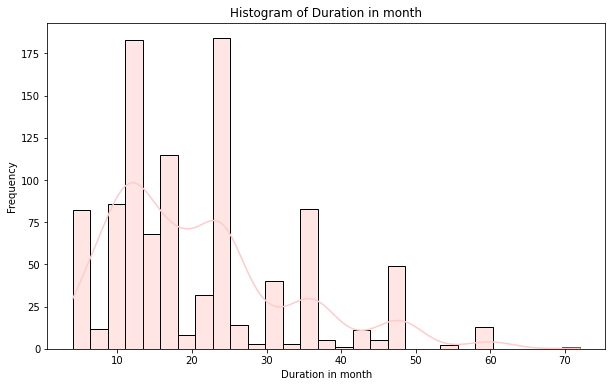

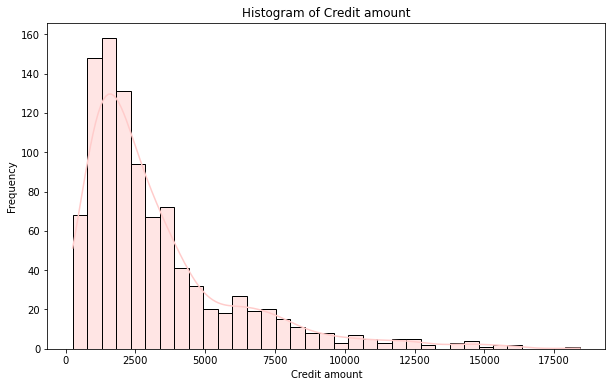

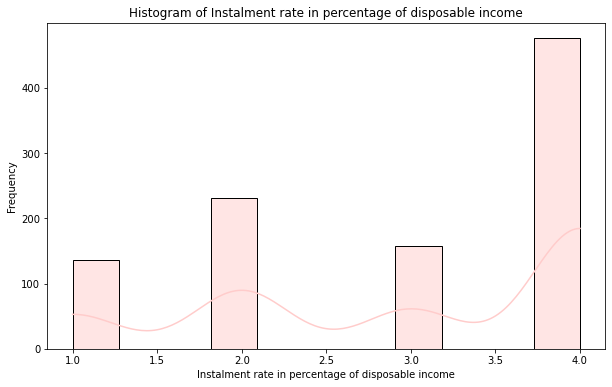

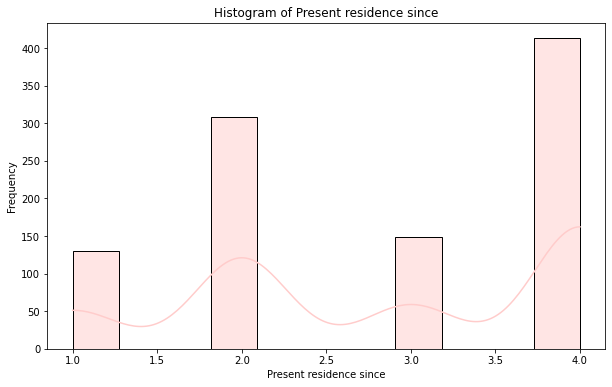

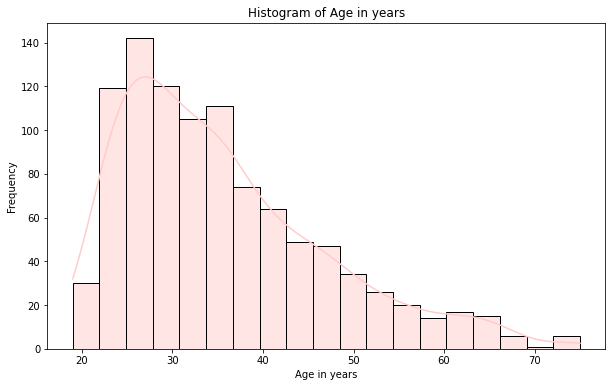

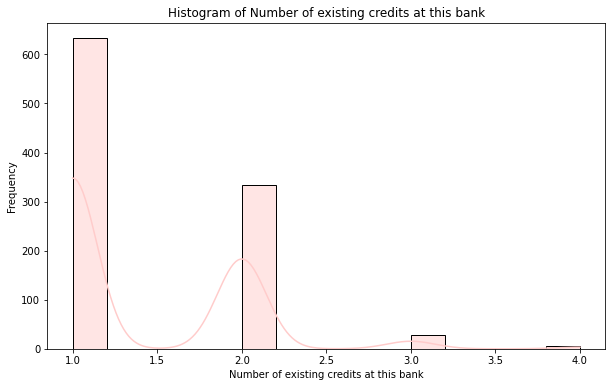

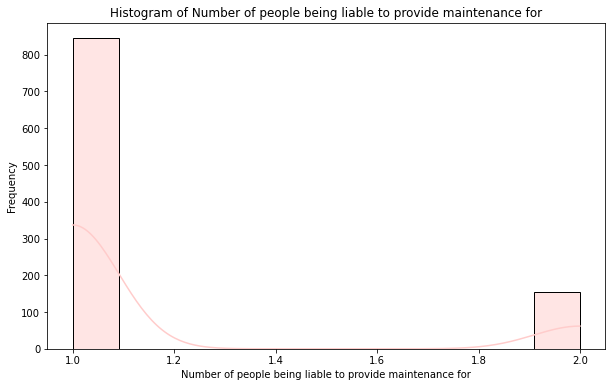

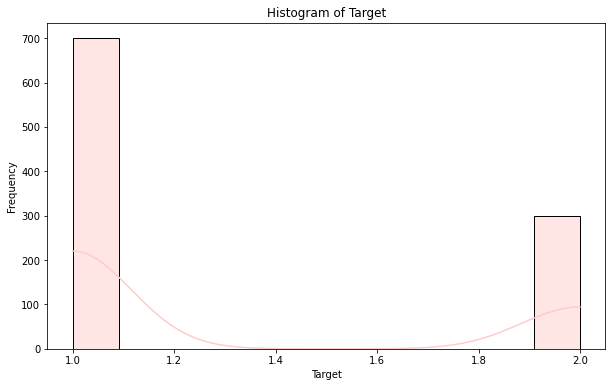

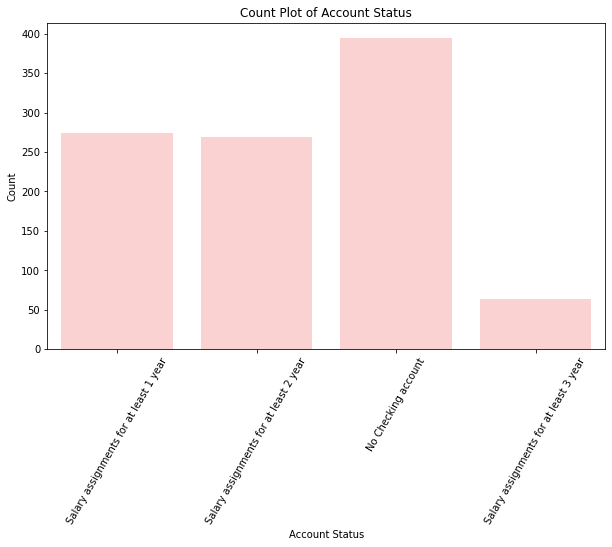

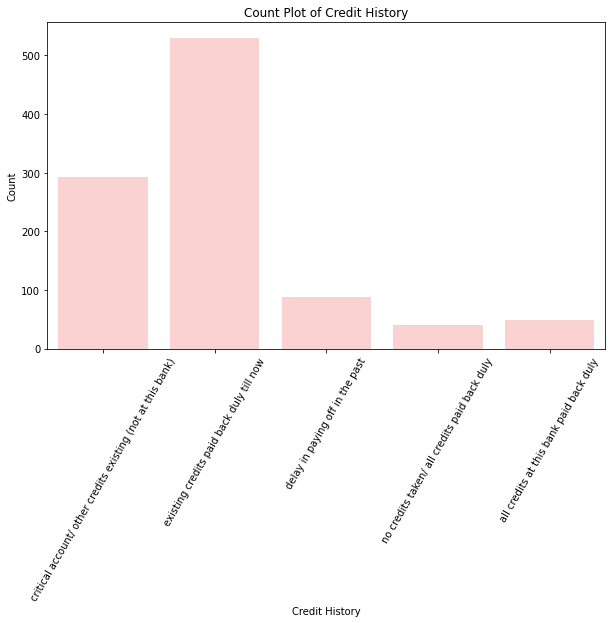

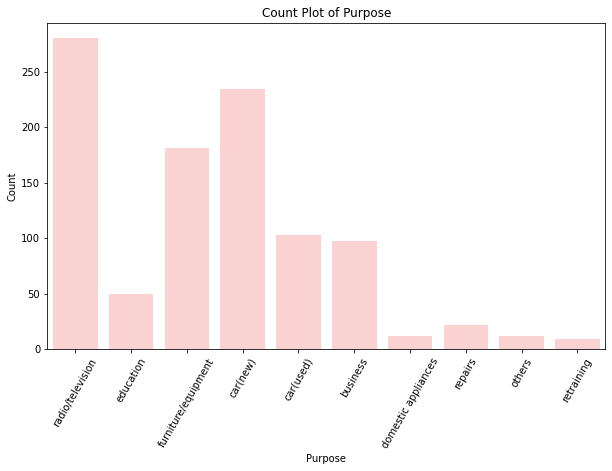

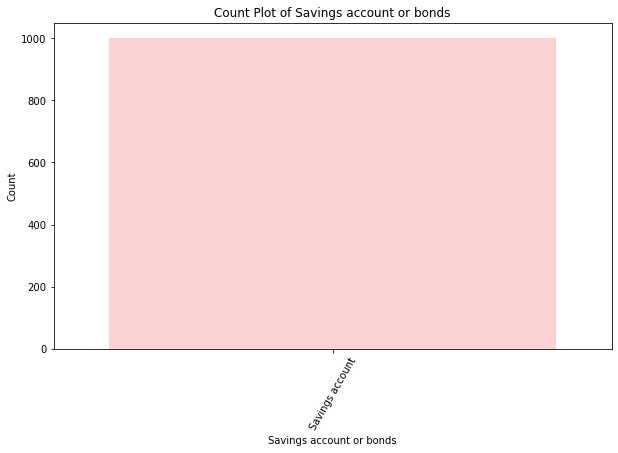

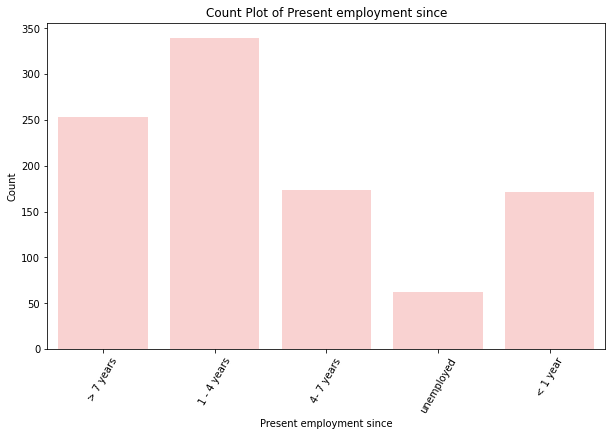

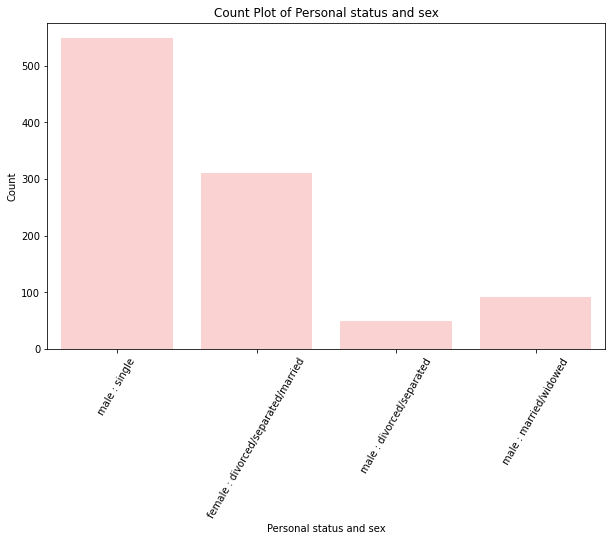

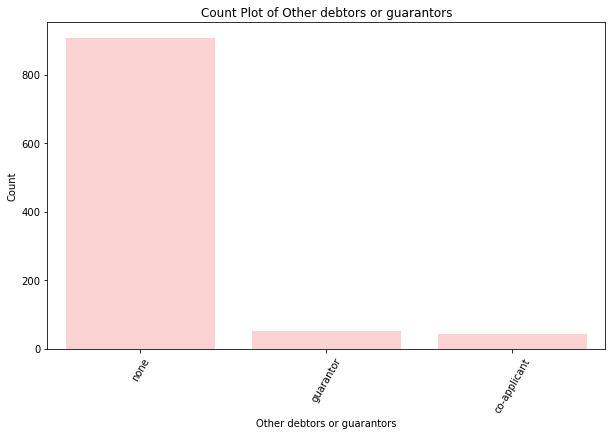

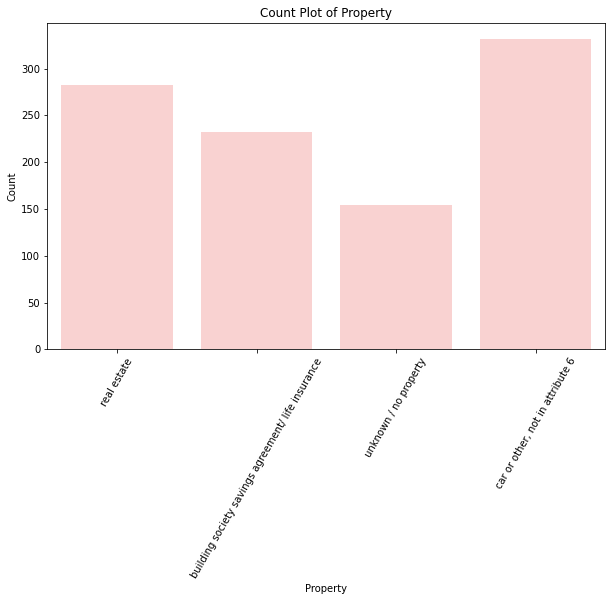

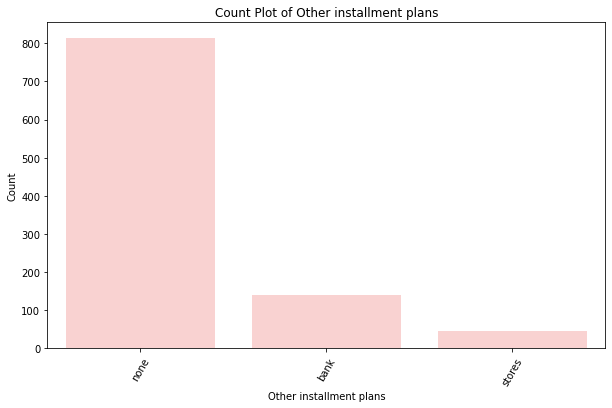

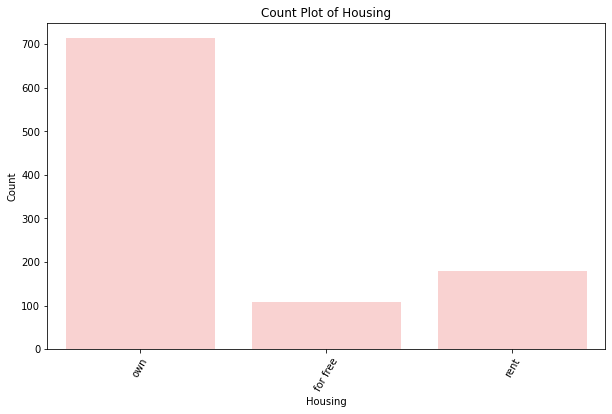

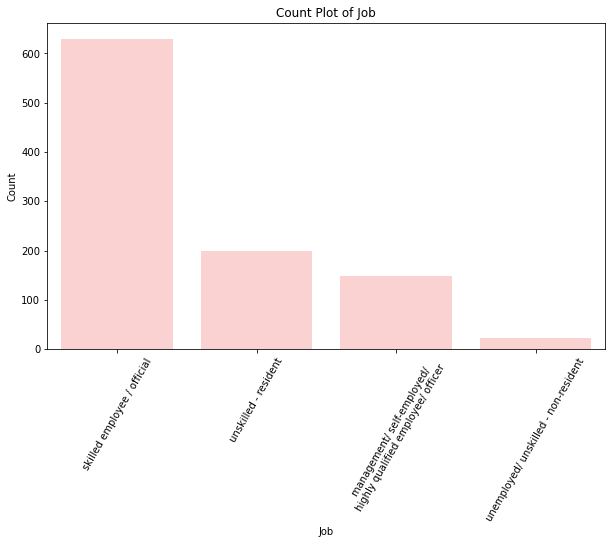

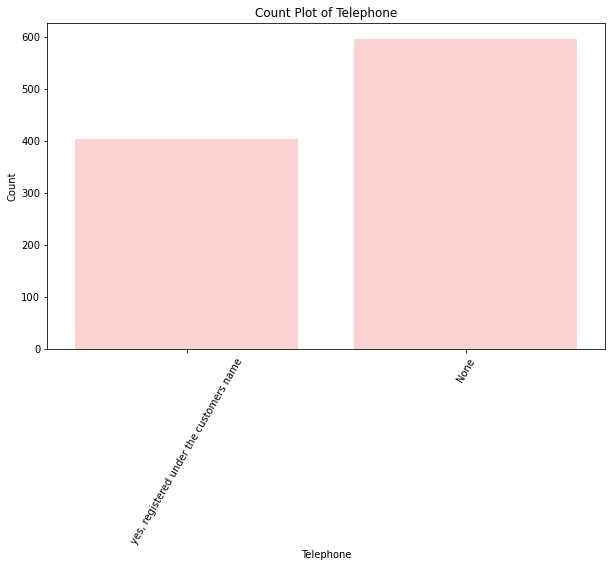

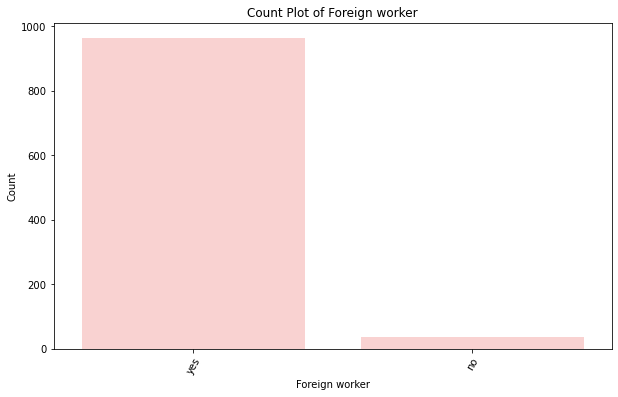

In [11]:
plot_histograms(Bank_Data)

Statistics for Duration in month:
Mean: 20.90
Mode: 24.00
Variance: 145.42
----------------------------------------


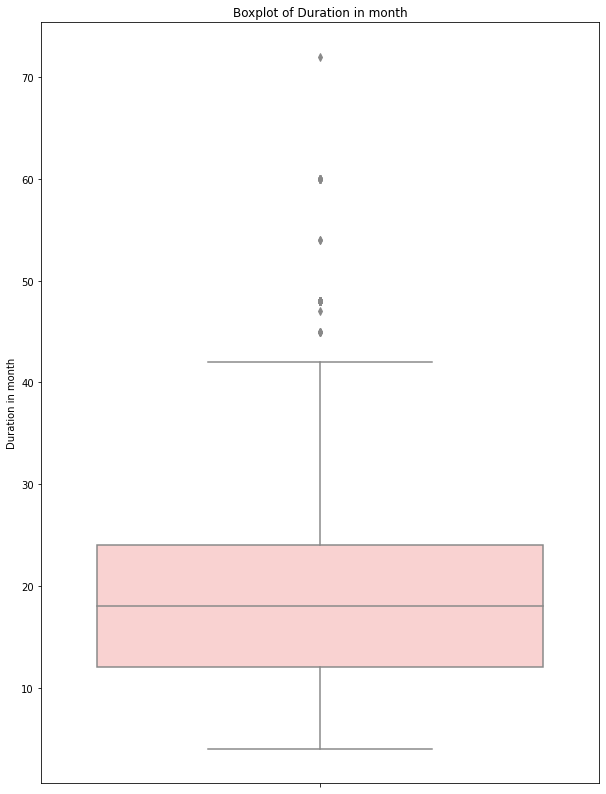

Statistics for Credit amount:
Mean: 3271.26
Mode: 1258.00
Variance: 7967843.47
----------------------------------------


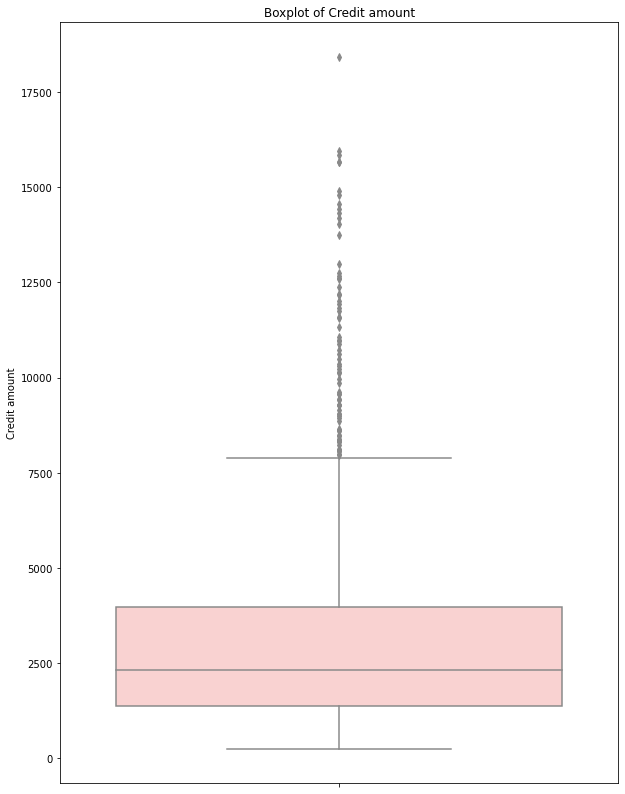

Statistics for Instalment rate in percentage of disposable income:
Mean: 2.97
Mode: 4.00
Variance: 1.25
----------------------------------------


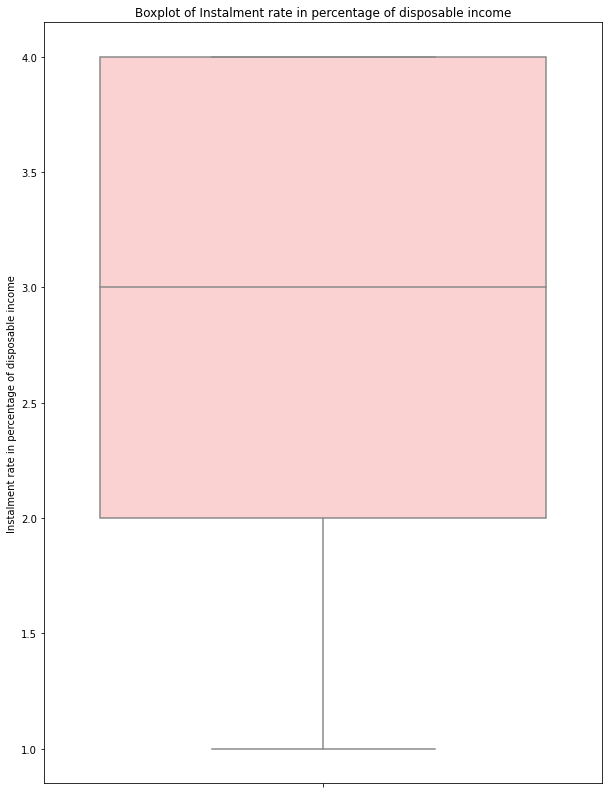

Statistics for Present residence since:
Mean: 2.85
Mode: 4.00
Variance: 1.22
----------------------------------------


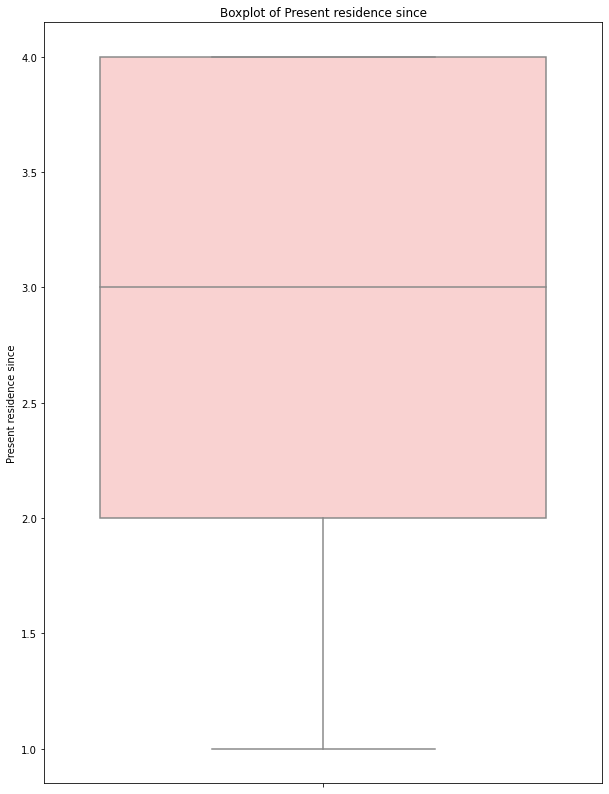

Statistics for Age in years:
Mean: 35.55
Mode: 27.00
Variance: 129.40
----------------------------------------


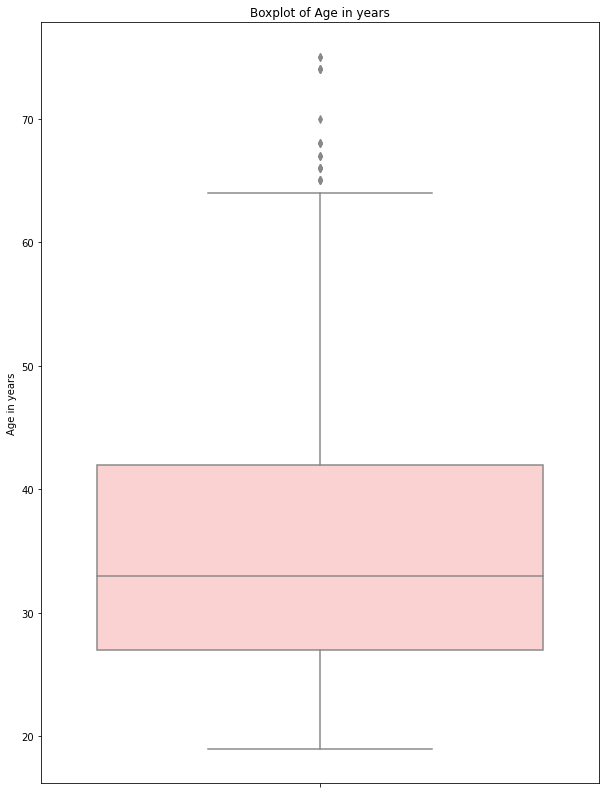

Statistics for Number of existing credits at this bank:
Mean: 1.41
Mode: 1.00
Variance: 0.33
----------------------------------------


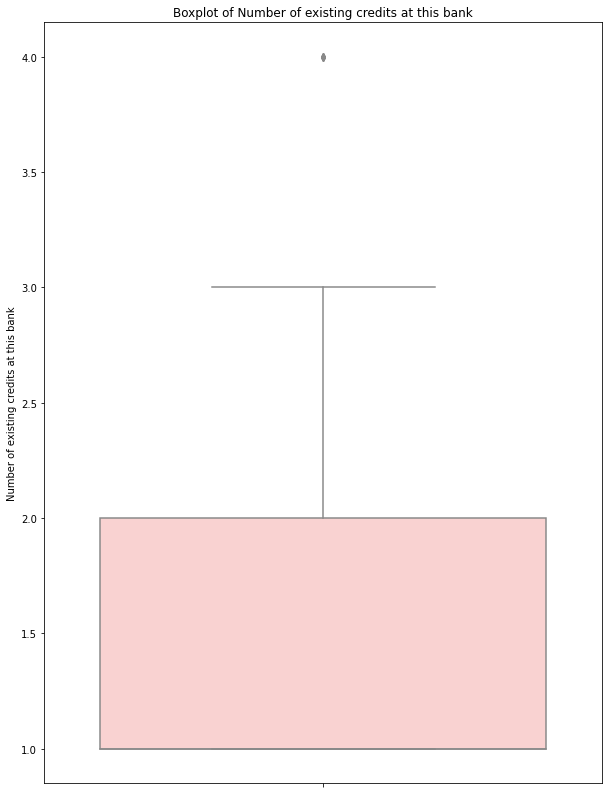

Statistics for Number of people being liable to provide maintenance for:
Mean: 1.16
Mode: 1.00
Variance: 0.13
----------------------------------------


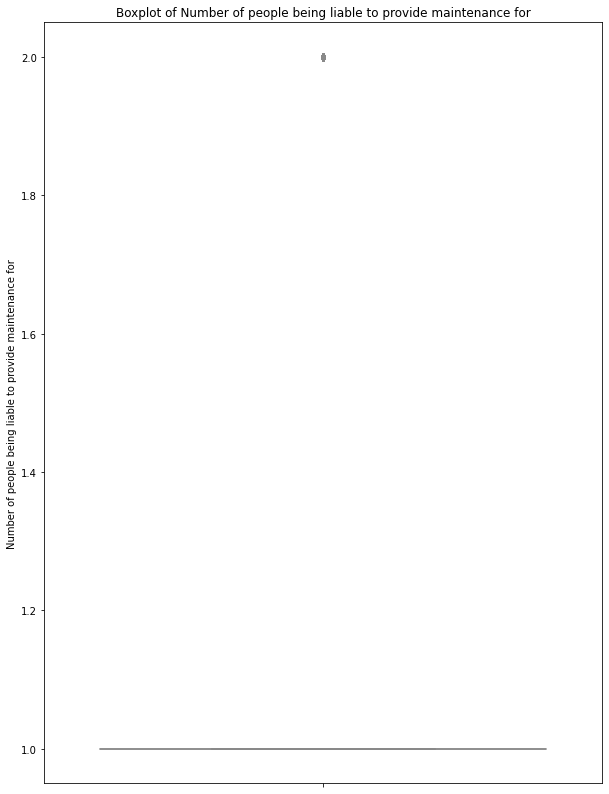

Statistics for Target:
Mean: 1.30
Mode: 1.00
Variance: 0.21
----------------------------------------


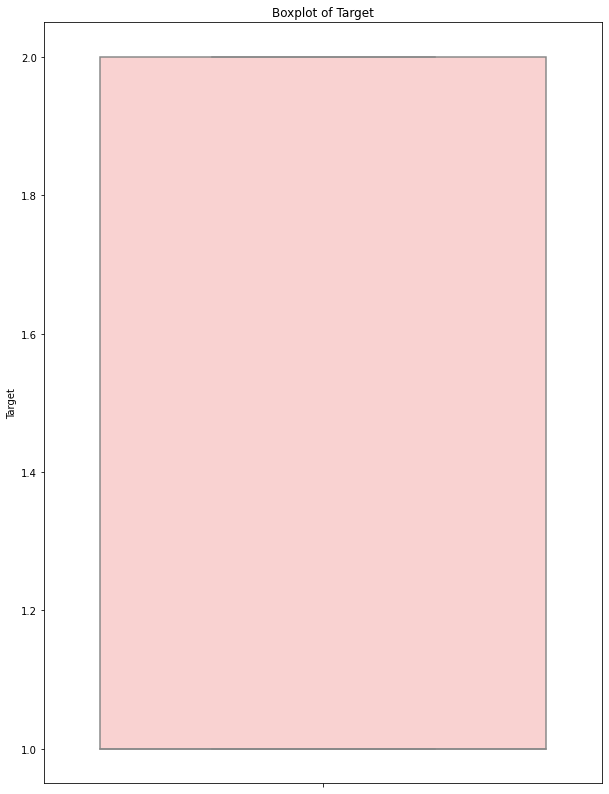

In [12]:
plot_boxplots_and_stats(Bank_Data)

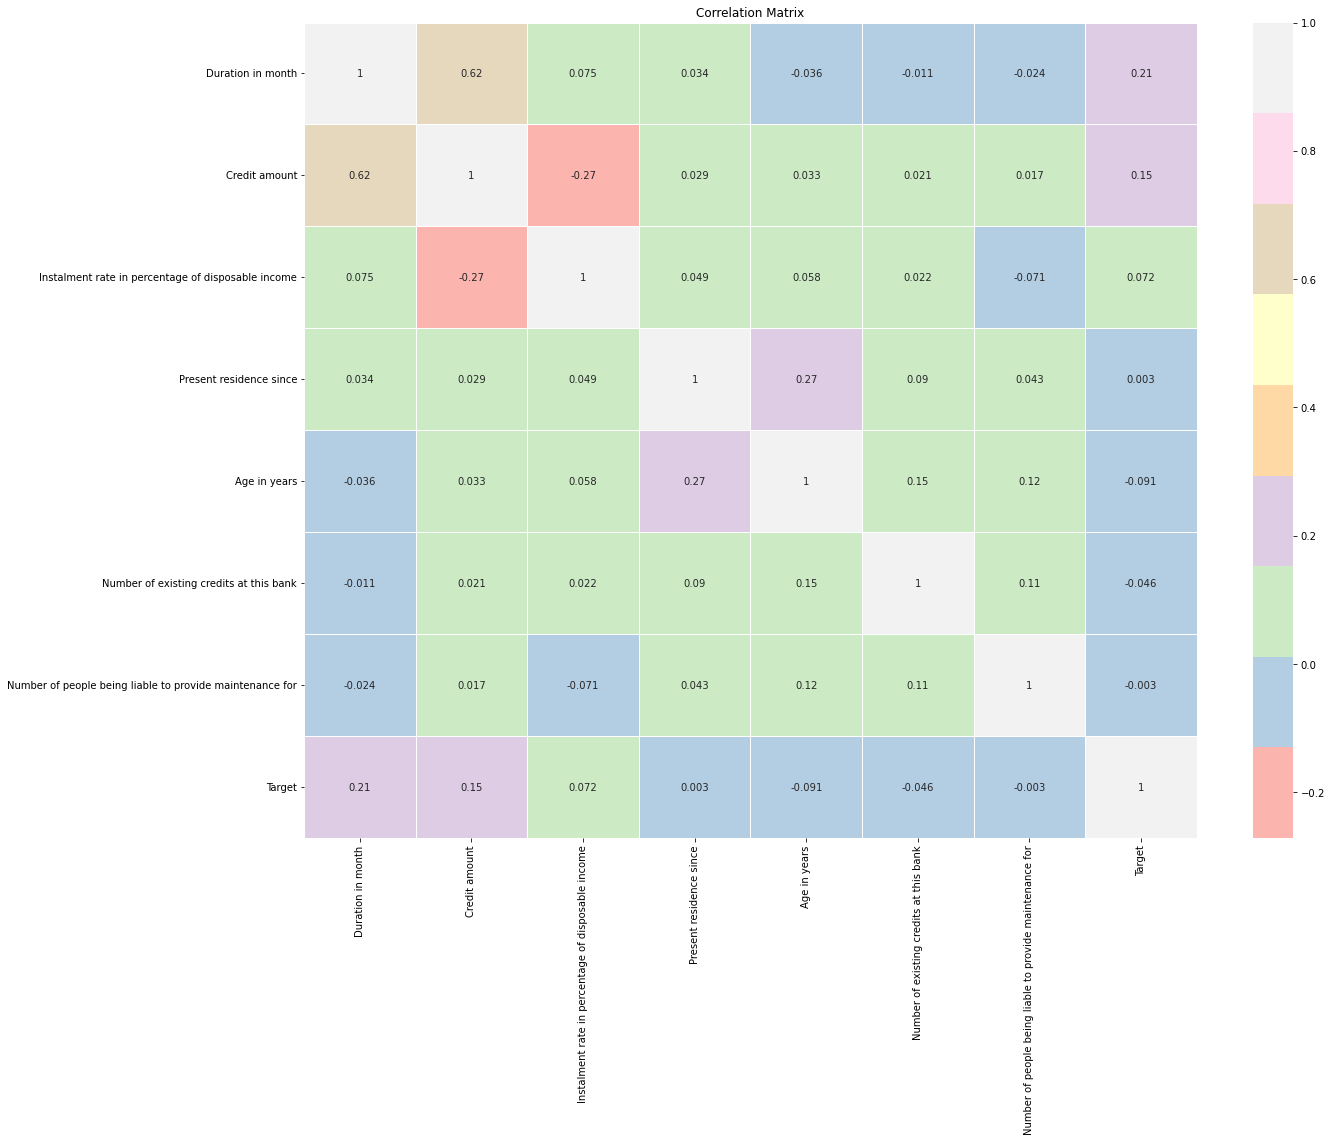

In [13]:
plt.figure(figsize=(20, 15))
sns.heatmap(Bank_Data.corr(), annot=True, cmap='Pastel1', linewidths=0.5, linecolor='white')
plt.title('Correlation Matrix')
plt.show()

#### 1.1.2 Data Manipulation<a id="part1.1.2"></a>

In [14]:
# Feature Selection

In [15]:
features = Bank_Data[['Age in years','Credit amount']]

In [16]:
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

In [17]:
# Create PCA instance and specify the number of components
pca = PCA(n_components=2)

# Fit the model and transform the data
scaled_features = pca.fit_transform(scaled_features)

### 1.2 K-Means Clustering<a id="part1.2"></a>

#### 1.2.1 Model 1<a id="part1.2.1"></a>

C:\Users\amelia\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


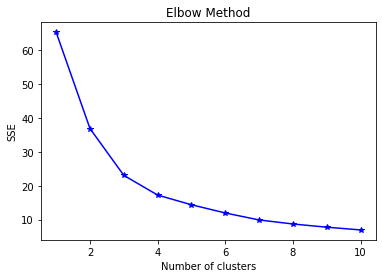

In [18]:
# Find the optimal number of clusters (i.e. K) using elbow method
sse = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, n_init=20, random_state=42)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)
plt.plot(range(1, 11), sse, 'b-*')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [19]:
kl = KneeLocator(
    range(1, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

3

In [20]:
silhouette_coefficients = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k , n_init=20, random_state=42)
    kmeans.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_coefficients.append(score)

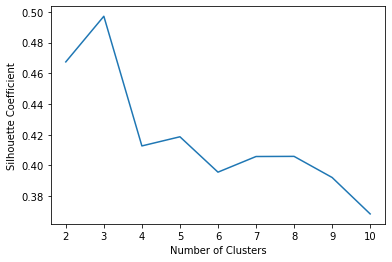

In [21]:
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [22]:
# Build the model using the optimal n_cluster
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
kmeans.fit(scaled_features)
y_pred = kmeans.predict(scaled_features)

In [23]:
# Final locations of the centroid
kmeans.cluster_centers_

array([[ 0.01058094,  0.30929322],
       [-0.11088827, -0.04669168],
       [ 0.28192587, -0.05985572]])

In [24]:
# The number of iterations required to converge
kmeans.n_iter_

8

In [25]:
kmeans.labels_[:5]

array([2, 1, 2, 0, 2])

In [26]:
# The lowest SSE value
kmeans.inertia_

23.070544431024413

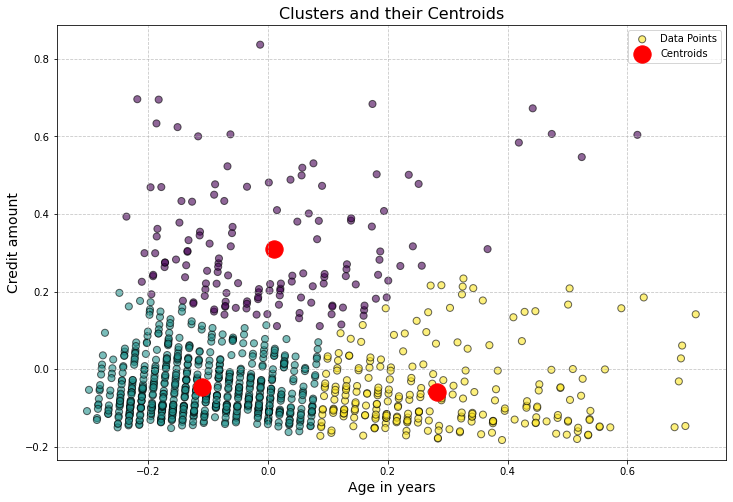

In [27]:
plt.figure(figsize=(12, 8))

# Get the minimum and maximum values of the data points
x_min, x_max = scaled_features[:, 0].min() - 1, scaled_features[:, 0].max() + 1
y_min, y_max = scaled_features[:, 1].min() - 1, scaled_features[:, 1].max() + 1

# Scatter plot for the clusters
plt.scatter( scaled_features[:, 0],  scaled_features[:, 1], c=y_pred, s=50, cmap='viridis', alpha=0.6, edgecolor='k', label='Data Points')

# Scatter plot for the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='o', label='Centroids')


# Adding labels and title
plt.xlabel('Age in years', fontsize=14)  
plt.ylabel('Credit amount', fontsize=14)
plt.title('Clusters and their Centroids', fontsize=16)

# Adding a legend
plt.legend()

# Improving the grid
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

In [28]:
Bank_Data_KM1 = Bank_Data.select_dtypes(include=[np.number])
Bank_Data_KM1['Cluster']=y_pred
Bank_Data_KM1.head()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target,Cluster
0,6,1169,4,4,67,2,1,1,2
1,48,5951,2,2,22,1,1,2,1
2,12,2096,2,3,49,1,2,1,2
3,42,7882,2,4,45,1,2,1,0
4,24,4870,3,4,53,2,2,2,2


Duration in month


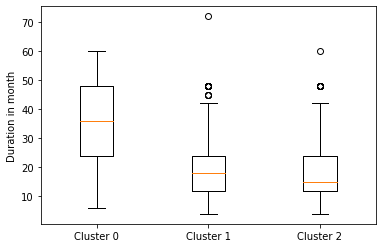

Credit amount


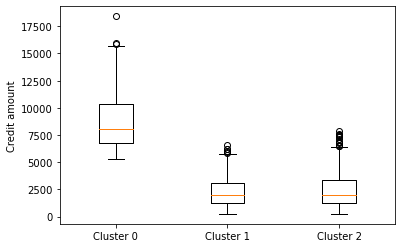

Instalment rate in percentage of disposable income


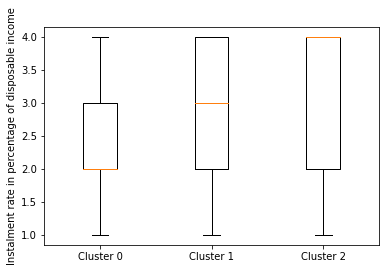

Present residence since


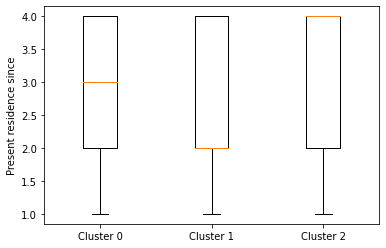

Age in years


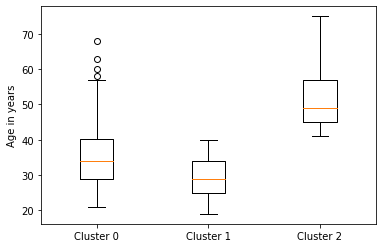

Number of existing credits at this bank


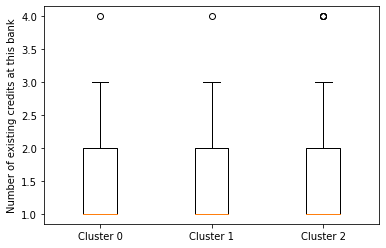

Number of people being liable to provide maintenance for


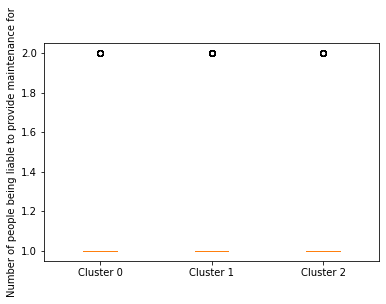

Target


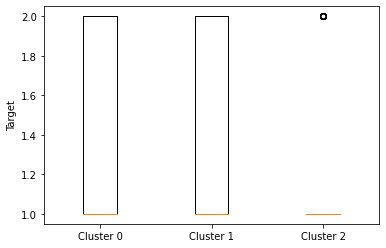

Cluster


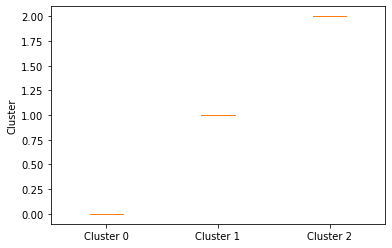

In [29]:
# Groupped Boxplots
i=0
for col in Bank_Data_KM1: 
    print(col) 
    plt.cla()
    plt.boxplot([Bank_Data_KM1.iloc[:,i][Bank_Data_KM1.Cluster==0].tolist(),
                 Bank_Data_KM1.iloc[:,i][Bank_Data_KM1.Cluster==1].tolist(),
                 Bank_Data_KM1.iloc[:,i][Bank_Data_KM1.Cluster==2].tolist()],
                 labels=('Cluster 0','Cluster 1','Cluster 2'))    
    plt.ylabel(col)
    plt.show()
    i=i+1

In [30]:
print(f"Silhouette Score for K-Means Clustering: {silhouette_score(scaled_features, kmeans.labels_)}")

Silhouette Score for K-Means Clustering: 0.4971878894763196


### 1.3 Hierarchical Clustering<a id="part1.3"></a>

Text(0, 0.5, 'Credit amount')

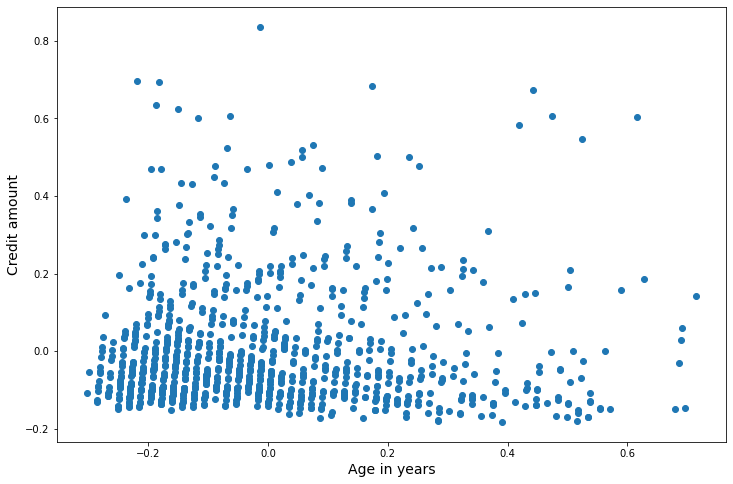

In [31]:
plt.figure(figsize=(12, 8))

plt.scatter(scaled_features[:,0], scaled_features[:,1])
plt.xlabel('Age in years', fontsize=14)  
plt.ylabel('Credit amount', fontsize=14)

In [32]:
# The full distance matrix 
print(cdist(scaled_features, scaled_features))

[[0.         0.84555356 0.32545051 ... 0.51824644 0.78659423 0.73847643]
 [0.84555356 0.         0.52673999 ... 0.40229185 0.22663176 0.11702992]
 [0.32545051 0.52673999 0.         ... 0.20889723 0.46449108 0.41588184]
 ...
 [0.51824644 0.40229185 0.20889723 ... 0.         0.27391313 0.28576367]
 [0.78659423 0.22663176 0.46449108 ... 0.27391313 0.         0.16638209]
 [0.73847643 0.11702992 0.41588184 ... 0.28576367 0.16638209 0.        ]]


In [33]:
print(cdist(scaled_features, scaled_features).shape)

(1000, 1000)


#### 1.3.1 Model 2<a id="part1.3.1"></a>

In [34]:
Z = shc.linkage(scaled_features, method ='ward') 
Z

array([[  34.        ,  855.        ,    0.        ,    2.        ],
       [ 421.        ,  984.        ,    0.        ,    2.        ],
       [ 165.        ,  223.        ,    0.        ,    2.        ],
       ...,
       [1993.        , 1994.        ,    4.28731737,  415.        ],
       [1992.        , 1995.        ,    4.96086901,  585.        ],
       [1996.        , 1997.        ,    6.90808741, 1000.        ]])

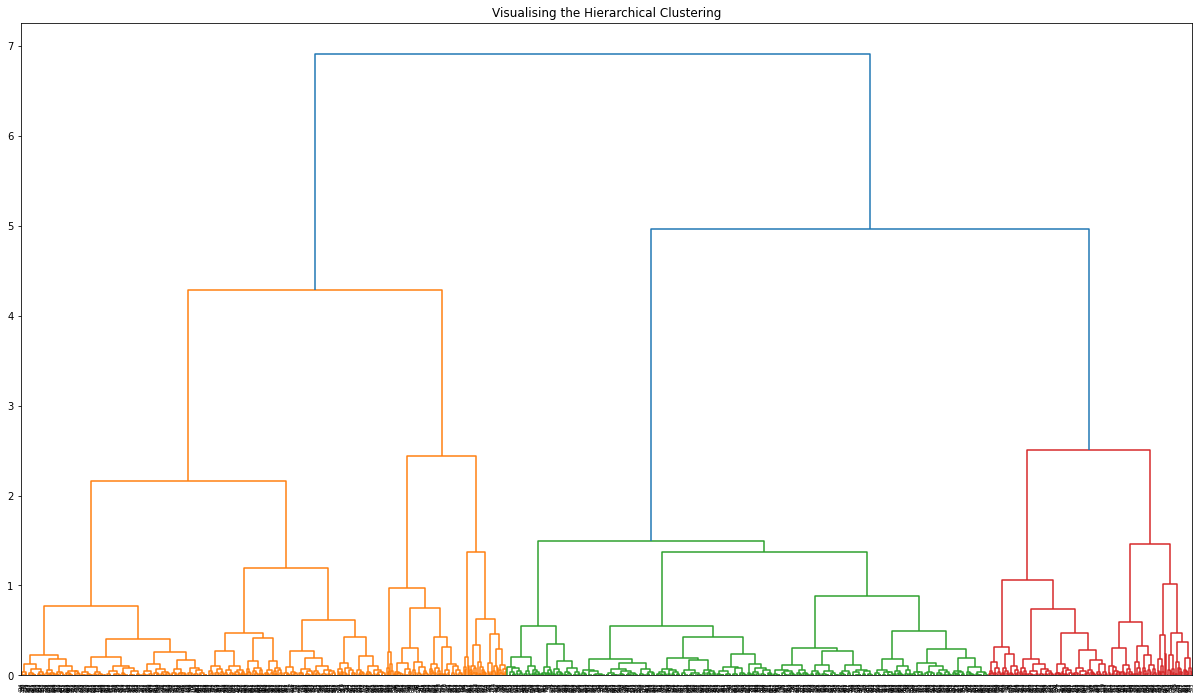

In [35]:
# Visualizing the hierarchical clustering through Dendrograms
plt.figure(figsize=(21, 12))
plt.title('Visualising the Hierarchical Clustering')
Dendrogram = shc.dendrogram(Z)
plt.xticks(rotation=90) 
plt.show()

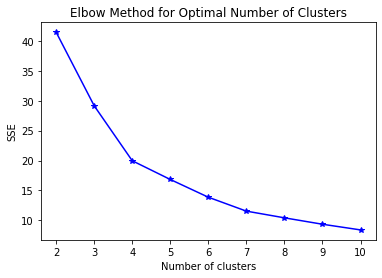

In [36]:
# Function to calculate SSE for hierarchical clustering
def calculate_sse(data, labels, cluster_centers):
    sse = 0
    for i, center in enumerate(cluster_centers):
        sse += np.sum((data[labels == i] - center) ** 2)
    return sse

# List to store SSE values
sse = []

# Loop over different number of clusters
for i in range(2, 11):
    ac = AgglomerativeClustering(n_clusters=i, linkage='ward')
    labels = ac.fit_predict(scaled_features)
    
    # Calculate cluster centers
    cluster_centers = np.array([scaled_features[labels == j].mean(axis=0) for j in range(i)])
    
    # Calculate SSE for the current number of clusters
    sse.append(calculate_sse(scaled_features, labels, cluster_centers))

# Plot the SSE values to visualize the elbow method
plt.plot(range(2, 11), sse, 'b-*')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [37]:
kl = KneeLocator(
    range(2, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

4

In [38]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    ac_i = AgglomerativeClustering(n_clusters = k,linkage='ward')
    silhouette_coefficients.append(silhouette_score(scaled_features, ac_i.fit_predict(scaled_features)))

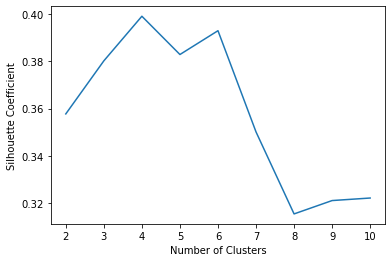

In [39]:
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [40]:
# Building the final model with n_clusters = 4
ac4 = AgglomerativeClustering(n_clusters = 4)
ac4

AgglomerativeClustering(n_clusters=4)

In [41]:
ac4.fit_predict(scaled_features)

array([1, 2, 3, 1, 1, 0, 3, 0, 1, 0, 2, 2, 2, 1, 2, 2, 3, 0, 0, 2, 3, 3,
       3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 0, 1, 3, 2, 0, 3, 3, 2, 2, 2, 0, 2,
       1, 3, 3, 2, 0, 2, 2, 0, 2, 2, 1, 2, 1, 0, 2, 2, 2, 3, 1, 0, 2, 1,
       2, 2, 3, 2, 0, 3, 3, 0, 3, 1, 0, 1, 0, 2, 0, 3, 2, 1, 3, 2, 2, 0,
       2, 2, 1, 1, 2, 2, 1, 1, 1, 3, 3, 0, 3, 2, 2, 3, 2, 0, 0, 0, 0, 3,
       2, 2, 0, 0, 3, 3, 0, 2, 2, 3, 2, 3, 2, 1, 2, 2, 3, 2, 3, 2, 0, 0,
       2, 3, 0, 3, 0, 1, 3, 3, 2, 0, 2, 2, 2, 2, 3, 3, 0, 3, 3, 3, 2, 0,
       0, 2, 3, 3, 3, 3, 3, 2, 3, 1, 3, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 1,
       3, 3, 2, 1, 0, 0, 3, 3, 3, 2, 1, 1, 2, 3, 1, 0, 0, 2, 2, 3, 2, 2,
       3, 3, 3, 2, 2, 2, 3, 0, 3, 2, 2, 1, 3, 3, 1, 1, 3, 3, 2, 2, 2, 1,
       2, 2, 2, 2, 0, 2, 0, 1, 2, 2, 2, 3, 3, 2, 3, 2, 0, 1, 3, 3, 2, 3,
       2, 2, 0, 2, 3, 3, 2, 2, 3, 3, 2, 0, 2, 0, 3, 2, 2, 1, 2, 1, 0, 1,
       2, 3, 0, 3, 1, 2, 2, 3, 0, 2, 0, 2, 2, 3, 0, 2, 2, 3, 3, 1, 0, 0,
       2, 0, 3, 3, 2, 0, 0, 1, 1, 0, 2, 3, 3, 2, 3,

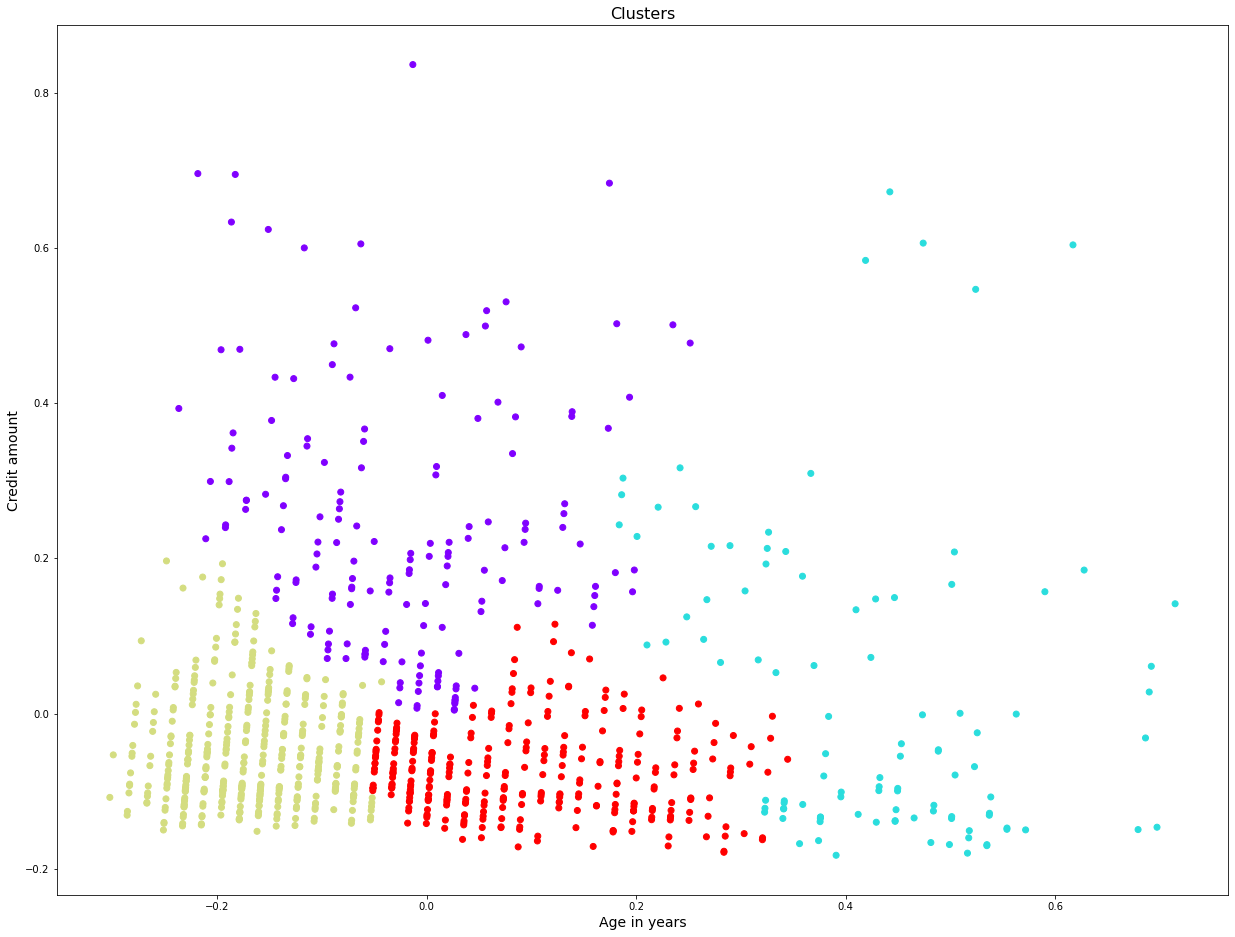

In [42]:
# scatter plot
plt.figure(figsize =(21, 16)) 
plt.scatter(scaled_features[:,0], scaled_features[:,1], 
            c = ac4.fit_predict(scaled_features), cmap ='rainbow')
plt.xlabel('Age in years', fontsize=14)  
plt.ylabel('Credit amount', fontsize=14)
plt.title('Clusters', fontsize=16)
plt.show() 

In [43]:
# Build the model using the optimal n_cluster

# Fit the model and assign each data point to the cluster
y_pred = ac4.fit_predict(scaled_features) # fit and then predict

Bank_Data_HC2 = Bank_Data.select_dtypes(include=[np.number])
Bank_Data_HC2['Cluster']=y_pred
Bank_Data_HC2.head()


,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target,Cluster
0,6,1169,4,4,67,2,1,1,1
1,48,5951,2,2,22,1,1,2,2
2,12,2096,2,3,49,1,2,1,3
3,42,7882,2,4,45,1,2,1,1
4,24,4870,3,4,53,2,2,2,1


Duration in month


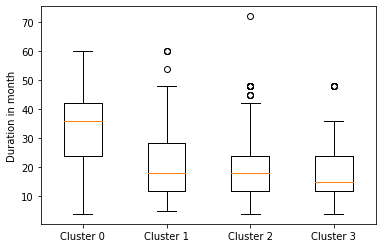

Credit amount


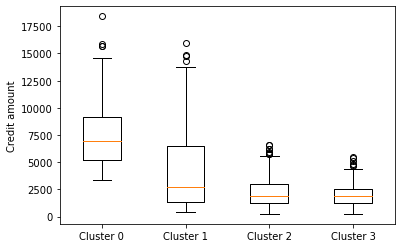

Instalment rate in percentage of disposable income


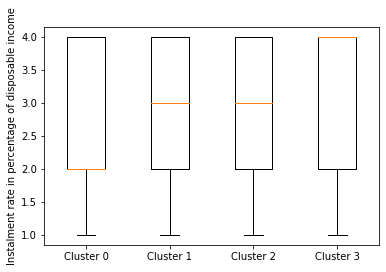

Present residence since


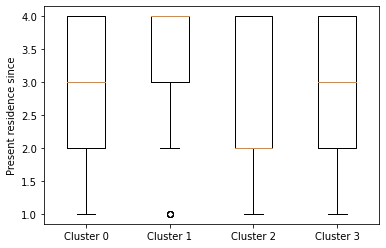

Age in years


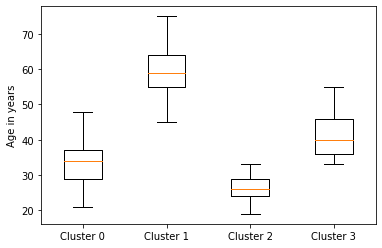

Number of existing credits at this bank


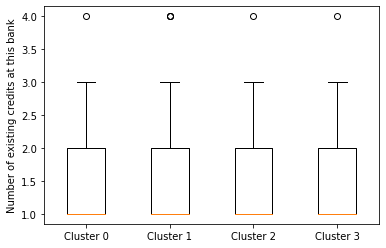

Number of people being liable to provide maintenance for


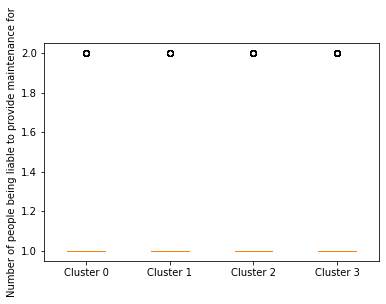

Target


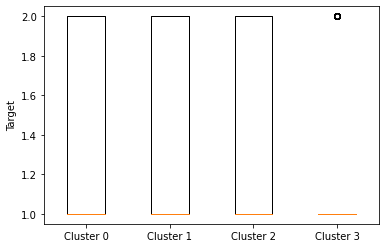

Cluster


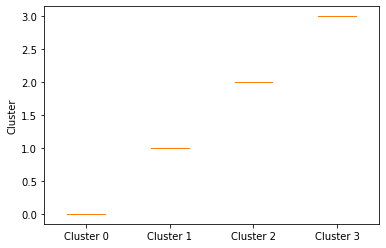

In [44]:
# Groupped Boxplots
i=0
for col in Bank_Data_HC2: 
    print(col) 
    plt.cla()
    plt.boxplot([Bank_Data_HC2.iloc[:,i][Bank_Data_HC2.Cluster==0].tolist(),
                 Bank_Data_HC2.iloc[:,i][Bank_Data_HC2.Cluster==1].tolist(),
                 Bank_Data_HC2.iloc[:,i][Bank_Data_HC2.Cluster==2].tolist(),
                 Bank_Data_HC2.iloc[:,i][Bank_Data_HC2.Cluster==3].tolist()],
                 labels=('Cluster 0','Cluster 1','Cluster 2','Cluster 3'))    
    plt.ylabel(col)
    plt.show()
    i=i+1

In [45]:
print(f"Silhoutte Score for Hierarchical Clustering using ward linkage: {silhouette_score(scaled_features, ac4.fit_predict(scaled_features))}")

Silhoutte Score for Hierarchical Clustering using ward linkage: 0.39915138260563104


#### 1.3.2 Model 3<a id="part1.3.2"></a>

In [46]:
# Task 1: Distance matrix and dendrograms
Z = shc.linkage(scaled_features, method ='average') 
Z # A condensed distance matrix

array([[3.40000000e+01, 8.55000000e+02, 0.00000000e+00, 2.00000000e+00],
       [4.21000000e+02, 9.84000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.65000000e+02, 2.23000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.99200000e+03, 1.99500000e+03, 4.93077929e-01, 9.59000000e+02],
       [1.97500000e+03, 1.99400000e+03, 5.24957293e-01, 4.10000000e+01],
       [1.99600000e+03, 1.99700000e+03, 6.02084059e-01, 1.00000000e+03]])

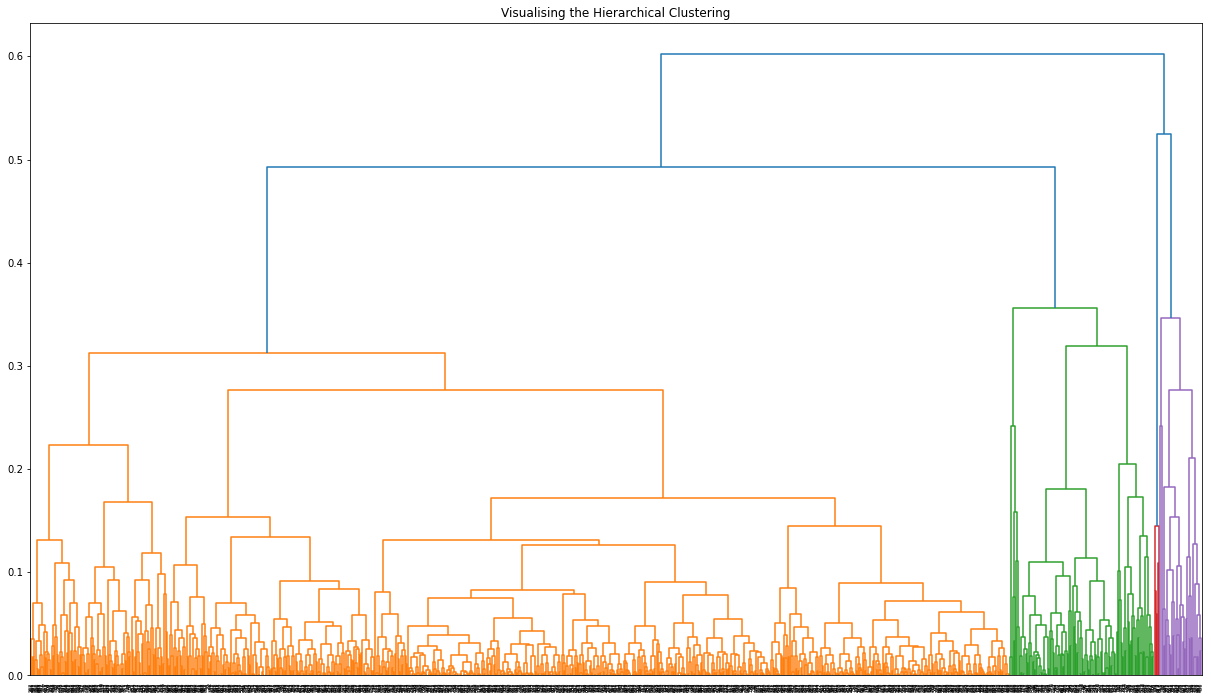

In [47]:
# Visualizing the hierarchical clustering through Dendrograms
plt.figure(figsize=(21, 12))
plt.title('Visualising the Hierarchical Clustering')
Dendrogram = shc.dendrogram(Z)
plt.xticks(rotation=90) 
plt.show()

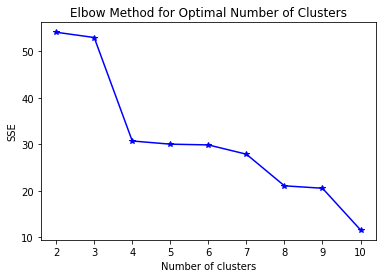

In [48]:
# Function to calculate SSE for hierarchical clustering
def calculate_sse(data, labels, cluster_centers):
    sse = 0
    for i, center in enumerate(cluster_centers):
        sse += np.sum((data[labels == i] - center) ** 2)
    return sse

# List to store SSE values
sse = []

# Loop over different number of clusters
for i in range(2, 11):
    ac = AgglomerativeClustering(n_clusters=i, linkage='average')
    labels = ac.fit_predict(scaled_features)
    
    # Calculate cluster centers
    cluster_centers = np.array([scaled_features[labels == j].mean(axis=0) for j in range(i)])
    
    # Calculate SSE for the current number of clusters
    sse.append(calculate_sse(scaled_features, labels, cluster_centers))

# Plot the SSE values to visualize the elbow method
plt.plot(range(2, 11), sse, 'b-*')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [49]:
kl = KneeLocator(
    range(2, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

4

In [50]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    ac_i = AgglomerativeClustering(n_clusters = k,linkage='average')
    silhouette_coefficients.append(silhouette_score(scaled_features, ac_i.fit_predict(scaled_features)))

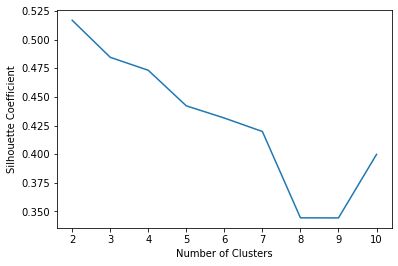

In [51]:
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [52]:
ac4 = AgglomerativeClustering(n_clusters = 4, linkage='average')
ac4

AgglomerativeClustering(linkage='average', n_clusters=4)

In [53]:
ac4.fit_predict(scaled_features)

array([0, 3, 3, 0, 0, 3, 0, 3, 0, 3, 3, 3, 3, 0, 3, 3, 0, 3, 1, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 0, 3, 3, 3, 3, 3, 0, 1, 3, 0,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 0, 1, 3, 3, 3, 3, 0, 0, 3, 3, 1,
       3, 3, 0, 0, 3, 3, 0, 2, 0, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 1, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0,
       3, 0, 3, 0, 3, 3, 3, 3, 3, 3, 0, 0, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 0, 3, 3, 3, 3, 1, 3, 3, 3, 0, 3, 3, 0, 0, 0, 3, 3, 3, 3, 0,
       3, 3, 3, 3, 3, 3, 1, 0, 3, 3, 3, 0, 3, 3, 3, 3, 1, 0, 3, 3, 3, 3,
       3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 0, 3, 0,
       3, 3, 3, 3, 0, 3, 3, 3, 1, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 1,
       3, 3, 3, 3, 3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 0,

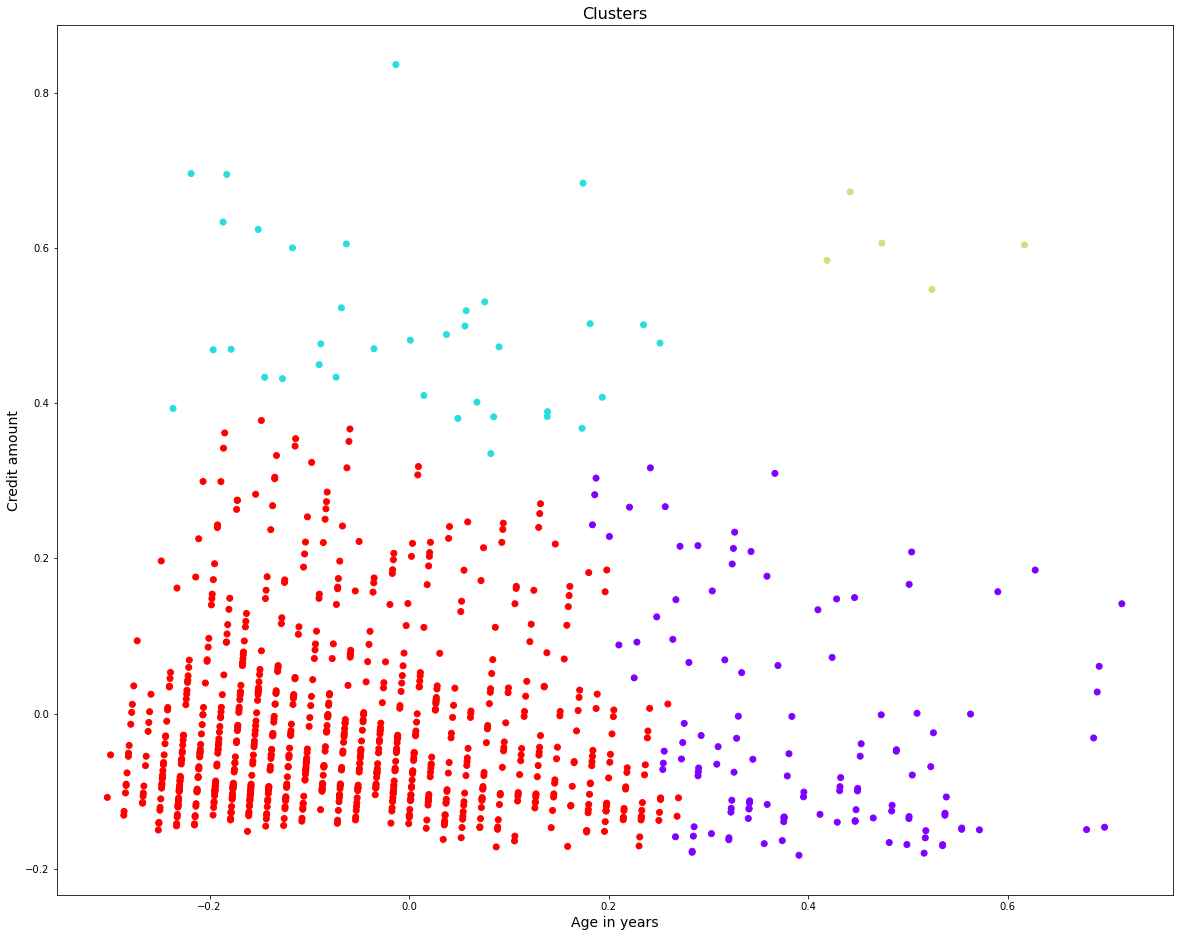

In [54]:
plt.figure(figsize =(20, 16)) 
plt.scatter(scaled_features[:,0], scaled_features[:,1], 
            c = ac4.fit_predict(scaled_features), cmap ='rainbow')
plt.xlabel('Age in years', fontsize=14)  
plt.ylabel('Credit amount', fontsize=14)
plt.title('Clusters', fontsize=16)
plt.show() 

In [55]:
# Build the model using the optimal n_cluster

# Fit the model and assign each data point to the cluster
y_pred = ac4.fit_predict(scaled_features) # fit and then predict


Bank_Data_HC3 = Bank_Data.select_dtypes(include=[np.number])
Bank_Data_HC3['Cluster']=y_pred
Bank_Data_HC3.head()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target,Cluster
0,6,1169,4,4,67,2,1,1,0
1,48,5951,2,2,22,1,1,2,3
2,12,2096,2,3,49,1,2,1,3
3,42,7882,2,4,45,1,2,1,0
4,24,4870,3,4,53,2,2,2,0


Duration in month


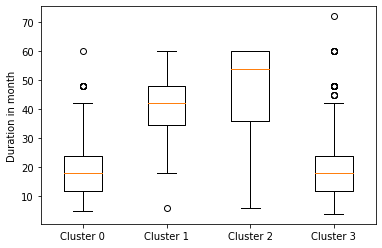

Credit amount


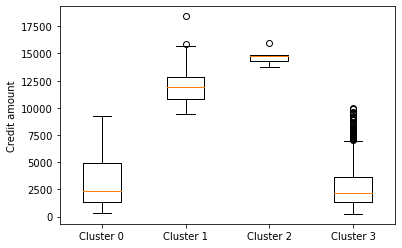

Instalment rate in percentage of disposable income


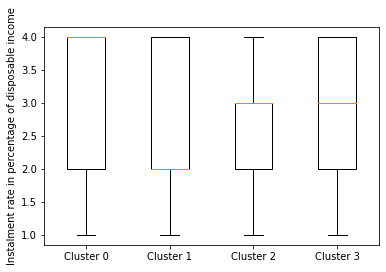

Present residence since


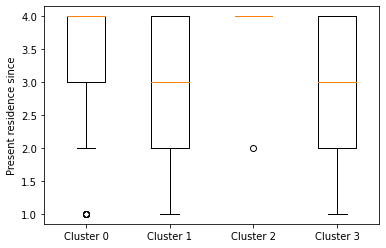

Age in years


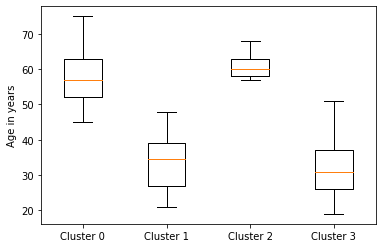

Number of existing credits at this bank


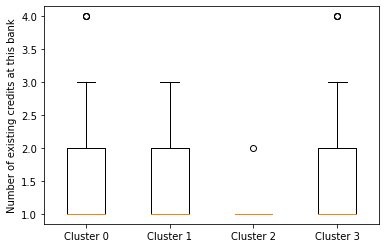

Number of people being liable to provide maintenance for


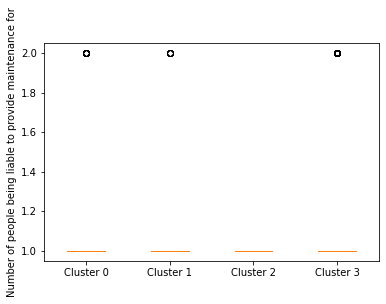

Target


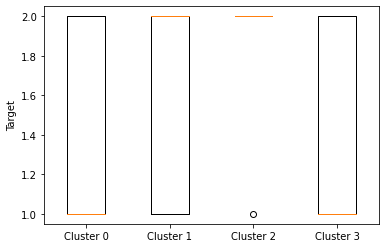

Cluster


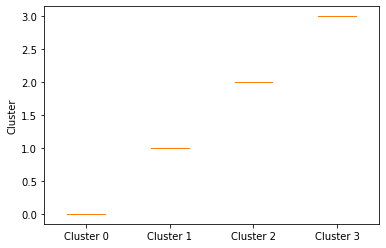

In [56]:
# Groupped Boxplots
i=0
for col in Bank_Data_HC3: 
    print(col) 
    plt.cla()
    plt.boxplot([Bank_Data_HC3.iloc[:,i][Bank_Data_HC3.Cluster==0].tolist(),
                 Bank_Data_HC3.iloc[:,i][Bank_Data_HC3.Cluster==1].tolist(),
                 Bank_Data_HC3.iloc[:,i][Bank_Data_HC3.Cluster==2].tolist(),
                 Bank_Data_HC3.iloc[:,i][Bank_Data_HC3.Cluster==3].tolist()],
                 labels=('Cluster 0','Cluster 1','Cluster 2','Cluster 3'))    
    plt.ylabel(col)
    plt.show()
    i=i+1

In [57]:
print(f"Silhoutte Score for Hierarchical Clustering using average linkage: {silhouette_score(scaled_features, ac4.fit_predict(scaled_features))}")

Silhoutte Score for Hierarchical Clustering using average linkage: 0.4732931666435614


#### 1.3.3 Model 4<a id="part1.3.3"></a>

In [58]:
# Complete Linkage
Z = shc.linkage(scaled_features, method ='complete')
Z

array([[3.40000000e+01, 8.55000000e+02, 0.00000000e+00, 2.00000000e+00],
       [4.21000000e+02, 9.84000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.65000000e+02, 2.23000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.96300000e+03, 1.99500000e+03, 8.79072434e-01, 1.11000000e+02],
       [1.99000000e+03, 1.99400000e+03, 1.04691634e+00, 8.89000000e+02],
       [1.99600000e+03, 1.99700000e+03, 1.24384262e+00, 1.00000000e+03]])

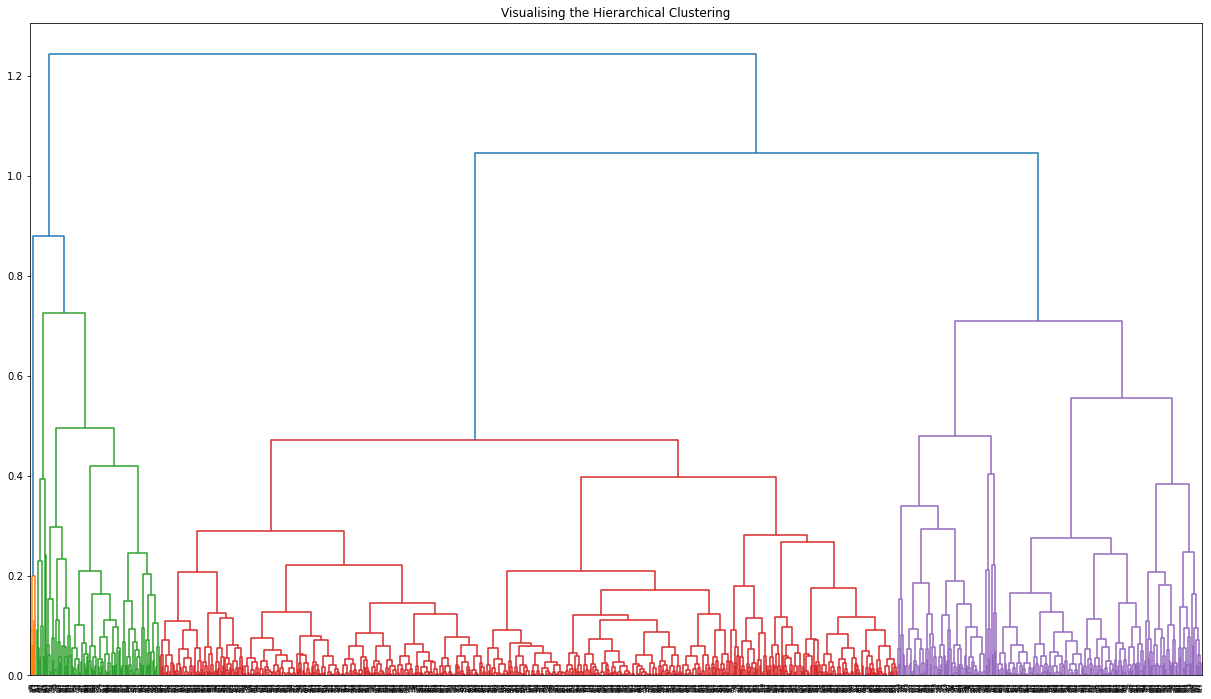

In [59]:
# Visualizing the hierarchical clustering through Dendrograms
plt.figure(figsize=(21, 12))
plt.title('Visualising the Hierarchical Clustering')
Dendrogram = shc.dendrogram(Z)
plt.xticks(rotation=90) 
plt.show()

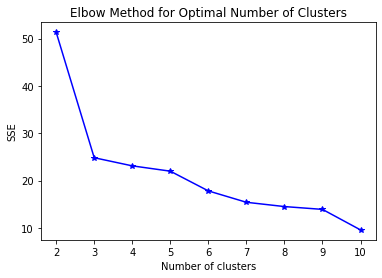

In [60]:
# Function to calculate SSE for hierarchical clustering
def calculate_sse(data, labels, cluster_centers):
    sse = 0
    for i, center in enumerate(cluster_centers):
        sse += np.sum((data[labels == i] - center) ** 2)
    return sse

# List to store SSE values
sse = []

# Loop over different number of clusters
for i in range(2, 11):
    ac = AgglomerativeClustering(n_clusters=i, linkage='complete')
    labels = ac.fit_predict(scaled_features)
    
    # Calculate cluster centers
    cluster_centers = np.array([scaled_features[labels == j].mean(axis=0) for j in range(i)])
    
    # Calculate SSE for the current number of clusters
    sse.append(calculate_sse(scaled_features, labels, cluster_centers))

# Plot the SSE values to visualize the elbow method
plt.plot(range(2, 11), sse, 'b-*')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [61]:
kl = KneeLocator(
    range(2, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

3

In [62]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    ac_i = AgglomerativeClustering(n_clusters = k,linkage='complete')
    silhouette_coefficients.append(silhouette_score(scaled_features, ac_i.fit_predict(scaled_features)))

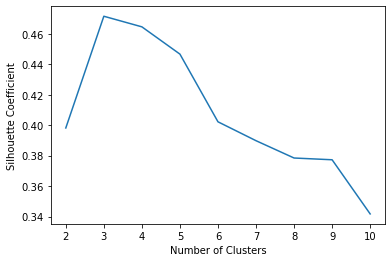

In [63]:
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [64]:
ac3 = AgglomerativeClustering(n_clusters = 3, linkage='complete')
ac3

AgglomerativeClustering(linkage='complete', n_clusters=3)

In [65]:
ac3.fit_predict(scaled_features)

array([1, 2, 1, 1, 1, 0, 1, 0, 1, 2, 2, 2, 2, 1, 2, 2, 1, 0, 0, 2, 1, 2,
       1, 1, 2, 2, 2, 1, 2, 1, 2, 2, 0, 1, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2,
       1, 2, 2, 2, 0, 2, 2, 0, 2, 2, 1, 2, 1, 0, 2, 2, 2, 1, 1, 0, 2, 1,
       2, 2, 2, 2, 0, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 2, 0,
       2, 2, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2,
       2, 2, 2, 0, 2, 1, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 0, 0,
       2, 1, 0, 2, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 0,
       0, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 1, 2, 1, 0, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 1, 2, 0, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 0, 1,
       2, 2, 0, 2, 1, 2, 2, 2, 0, 2, 0, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0,
       2, 0, 1, 1, 2, 0, 1, 1, 1, 0, 2, 1, 2, 2, 1,

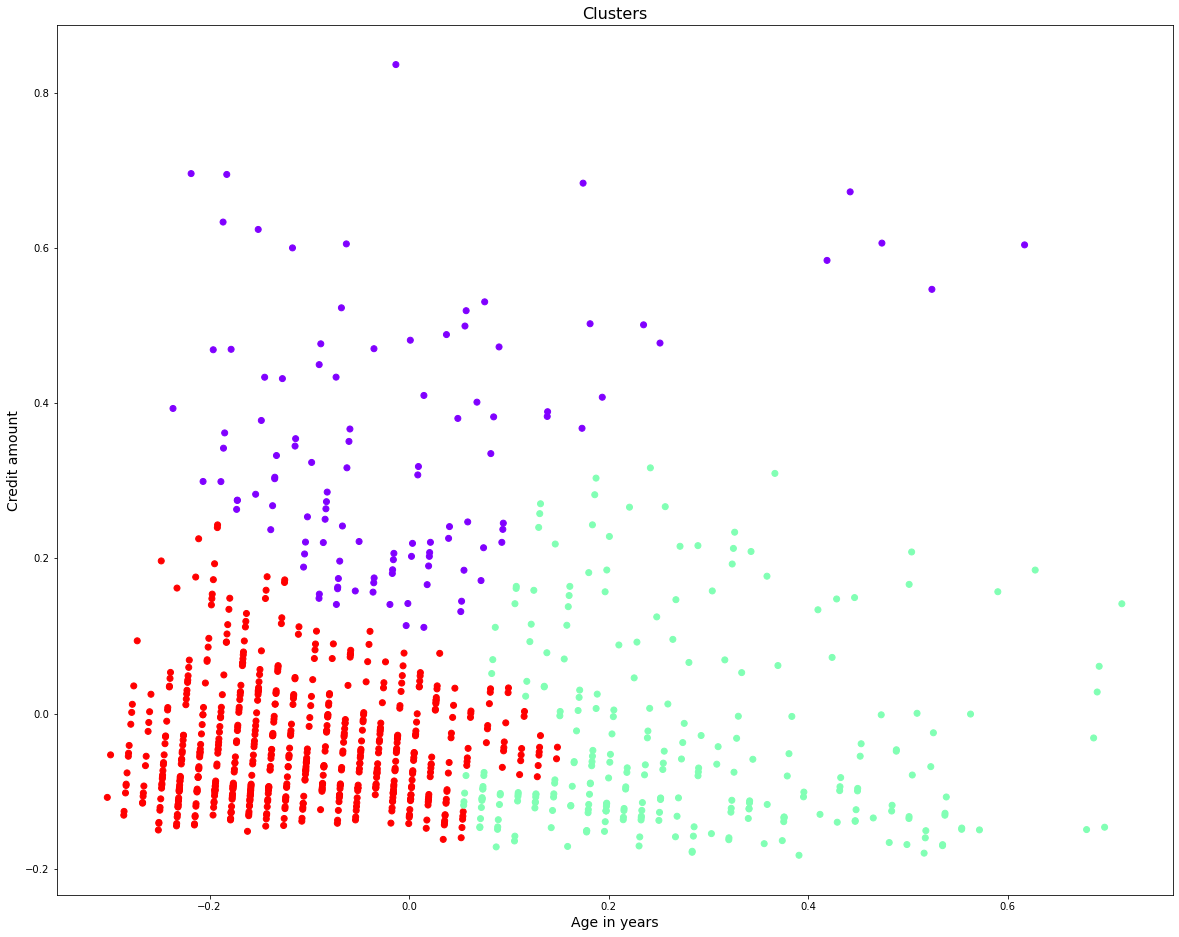

In [66]:
plt.figure(figsize =(20, 16)) 
plt.scatter(scaled_features[:,0], scaled_features[:,1], 
            c = ac3.fit_predict(scaled_features), cmap ='rainbow')
plt.xlabel('Age in years', fontsize=14)  
plt.ylabel('Credit amount', fontsize=14)
plt.title('Clusters', fontsize=16)
plt.show() 

In [67]:
# Build the model using the optimal n_cluster

# Fit the model and assign each data point to the cluster
y_pred = ac3.fit_predict(scaled_features) # fit and then predict

Bank_Data_HC4 = Bank_Data.select_dtypes(include=[np.number])
Bank_Data_HC4['Cluster']=y_pred
Bank_Data_HC4.head()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target,Cluster
0,6,1169,4,4,67,2,1,1,1
1,48,5951,2,2,22,1,1,2,2
2,12,2096,2,3,49,1,2,1,1
3,42,7882,2,4,45,1,2,1,1
4,24,4870,3,4,53,2,2,2,1


Duration in month


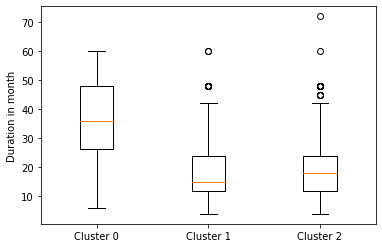

Credit amount


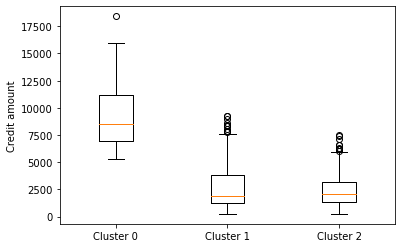

Instalment rate in percentage of disposable income


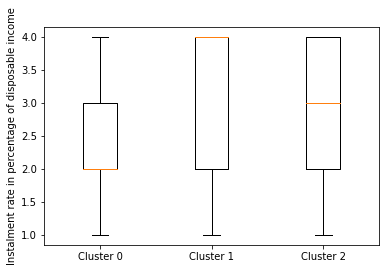

Present residence since


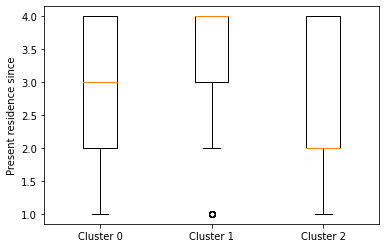

Age in years


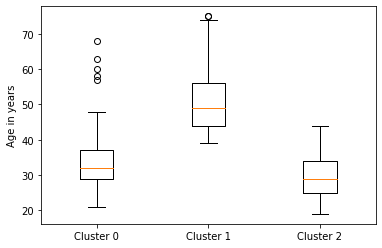

Number of existing credits at this bank


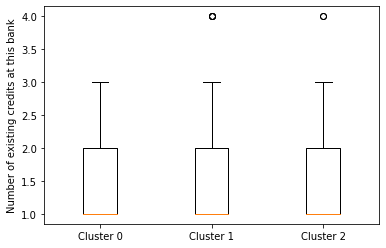

Number of people being liable to provide maintenance for


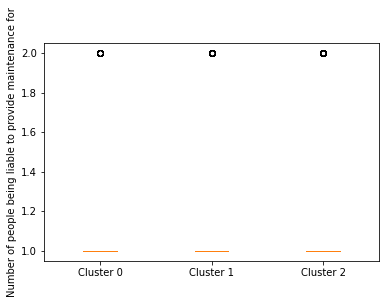

Target


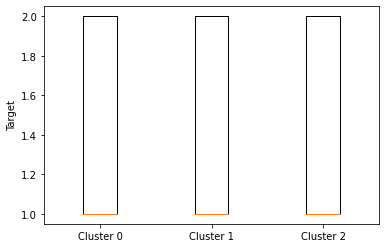

Cluster


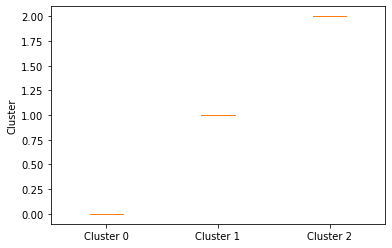

In [68]:
# Groupped Boxplots
i=0
for col in Bank_Data_HC4: 
    print(col) 
    plt.cla()
    plt.boxplot([Bank_Data_HC4.iloc[:,i][Bank_Data_HC4.Cluster==0].tolist(),
                 Bank_Data_HC4.iloc[:,i][Bank_Data_HC4.Cluster==1].tolist(),
                 Bank_Data_HC4.iloc[:,i][Bank_Data_HC4.Cluster==2].tolist()],
                 labels=('Cluster 0','Cluster 1','Cluster 2'))    
    plt.ylabel(col)
    plt.show()
    i=i+1

In [69]:
scaled_features

array([[ 0.55374135, -0.14910999],
       [-0.23262653,  0.16167351],
       [ 0.23594516, -0.07894152],
       ...,
       [ 0.03561106, -0.13813865],
       [-0.22833417, -0.0649176 ],
       [-0.14803291,  0.08080373]])

In [70]:
ac3.fit_predict(scaled_features)

array([1, 2, 1, 1, 1, 0, 1, 0, 1, 2, 2, 2, 2, 1, 2, 2, 1, 0, 0, 2, 1, 2,
       1, 1, 2, 2, 2, 1, 2, 1, 2, 2, 0, 1, 2, 2, 0, 2, 2, 2, 2, 2, 1, 2,
       1, 2, 2, 2, 0, 2, 2, 0, 2, 2, 1, 2, 1, 0, 2, 2, 2, 1, 1, 0, 2, 1,
       2, 2, 2, 2, 0, 1, 1, 1, 1, 1, 2, 1, 0, 2, 1, 1, 2, 1, 1, 2, 2, 0,
       2, 2, 1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2,
       2, 2, 2, 0, 2, 1, 0, 2, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 0, 0,
       2, 1, 0, 2, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 0,
       0, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       2, 1, 2, 1, 0, 2, 1, 1, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1,
       2, 2, 2, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 1, 2, 0, 1, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 0, 1,
       2, 2, 0, 2, 1, 2, 2, 2, 0, 2, 0, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 0,
       2, 0, 1, 1, 2, 0, 1, 1, 1, 0, 2, 1, 2, 2, 1,

In [71]:
print(f"Silhouette Score for Hierarchical Clustering using complete linkage: {silhouette_score(scaled_features, ac3.fit_predict(scaled_features))}")

Silhouette Score for Hierarchical Clustering using complete linkage: 0.47153495799796635


#### 1.3.4 Model 5<a id="part1.3.4"></a>

In [72]:
# Task 1: Distance matrix and dendrograms
Z = shc.linkage(scaled_features, method ='single') 
Z # A condensed distance matrix

array([[3.40000000e+01, 8.55000000e+02, 0.00000000e+00, 2.00000000e+00],
       [4.21000000e+02, 9.84000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.65000000e+02, 2.23000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [8.18000000e+02, 1.99400000e+03, 1.81249368e-01, 9.94000000e+02],
       [1.99500000e+03, 1.99600000e+03, 1.98392107e-01, 9.99000000e+02],
       [9.15000000e+02, 1.99700000e+03, 2.20813601e-01, 1.00000000e+03]])

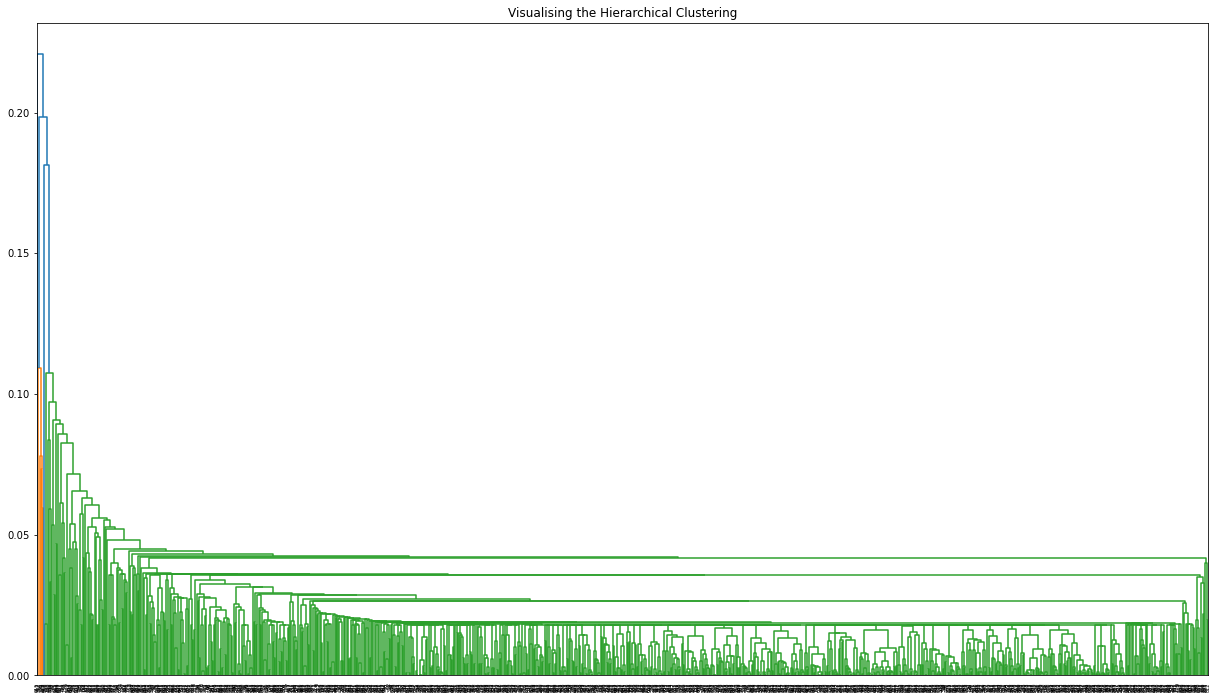

In [73]:
# Visualizing the hierarchical clustering through Dendrograms
plt.figure(figsize=(21, 12))
plt.title('Visualising the Hierarchical Clustering')
Dendrogram = shc.dendrogram(Z)
plt.xticks(rotation=90) 
plt.show()

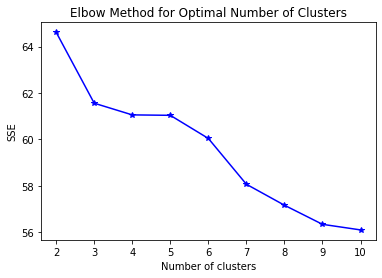

In [74]:
# Function to calculate SSE for hierarchical clustering
def calculate_sse(data, labels, cluster_centers):
    sse = 0
    for i, center in enumerate(cluster_centers):
        sse += np.sum((data[labels == i] - center) ** 2)
    return sse

# List to store SSE values
sse = []

# Loop over different number of clusters
for i in range(2, 11):
    ac = AgglomerativeClustering(n_clusters=i, linkage='single')
    labels = ac.fit_predict(scaled_features)
    
    # Calculate cluster centers
    cluster_centers = np.array([scaled_features[labels == j].mean(axis=0) for j in range(i)])
    
    # Calculate SSE for the current number of clusters
    sse.append(calculate_sse(scaled_features, labels, cluster_centers))

# Plot the SSE values to visualize the elbow method
plt.plot(range(2, 11), sse, 'b-*')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [75]:
kl = KneeLocator(
    range(2, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

3

In [76]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    ac_i = AgglomerativeClustering(n_clusters = k,linkage='single')
    silhouette_coefficients.append(silhouette_score(scaled_features, ac_i.fit_predict(scaled_features)))

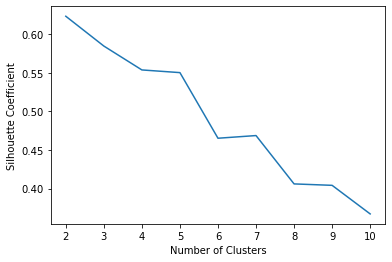

In [77]:
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [78]:
ac3 = AgglomerativeClustering(n_clusters = 3, linkage='single')
ac3

AgglomerativeClustering(linkage='single', n_clusters=3)

In [79]:
ac3.fit_predict(scaled_features)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

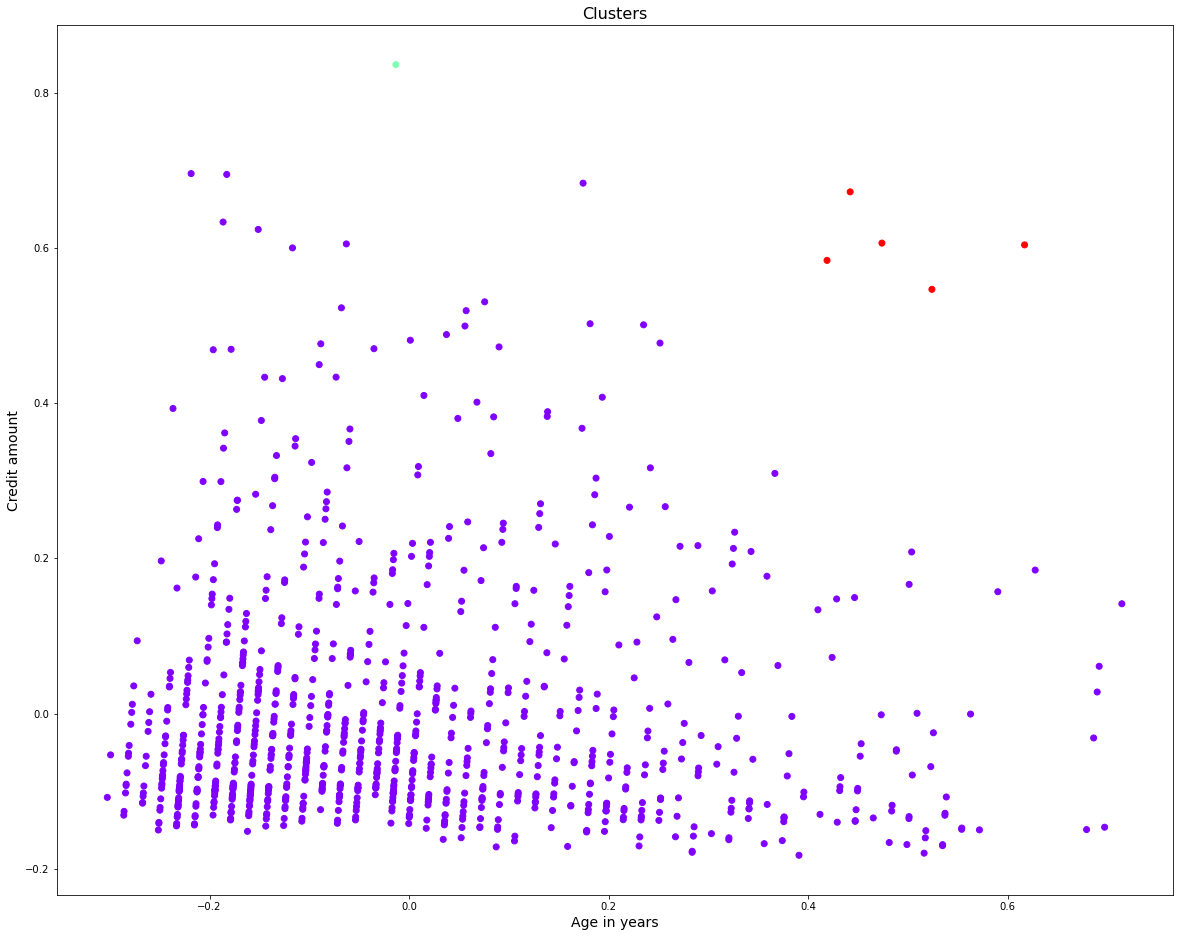

In [80]:
plt.figure(figsize =(20, 16)) 
plt.scatter(scaled_features[:,0], scaled_features[:,1], 
            c = ac3.fit_predict(scaled_features), cmap ='rainbow')
plt.xlabel('Age in years', fontsize=14)  
plt.ylabel('Credit amount', fontsize=14)
plt.title('Clusters', fontsize=16)
plt.show() 

In [81]:
# Build the model using the optimal n_cluster

# Fit the model and assign each data point to the cluster
y_pred = ac3.fit_predict(scaled_features) # fit and then predict

Bank_Data_HC5 = Bank_Data.select_dtypes(include=[np.number])
Bank_Data_HC5['Cluster']=y_pred
Bank_Data_HC5.head()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target,Cluster
0,6,1169,4,4,67,2,1,1,0
1,48,5951,2,2,22,1,1,2,0
2,12,2096,2,3,49,1,2,1,0
3,42,7882,2,4,45,1,2,1,0
4,24,4870,3,4,53,2,2,2,0


Duration in month


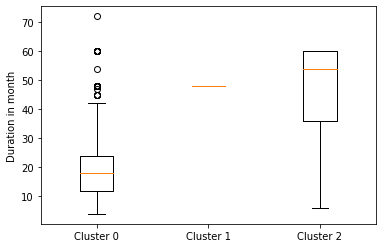

Credit amount


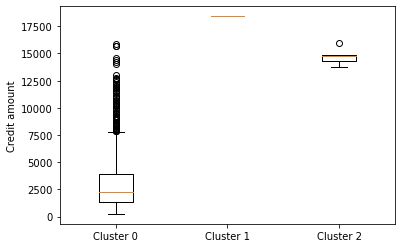

Instalment rate in percentage of disposable income


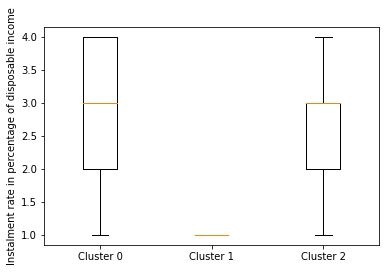

Present residence since


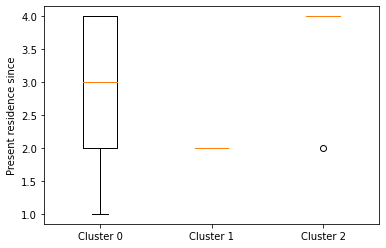

Age in years


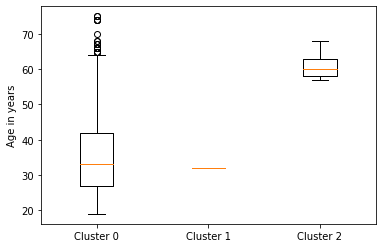

Number of existing credits at this bank


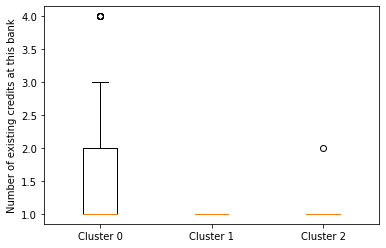

Number of people being liable to provide maintenance for


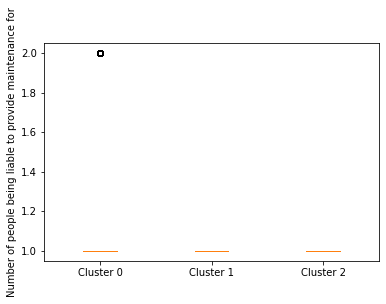

Target


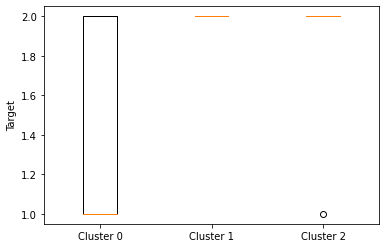

Cluster


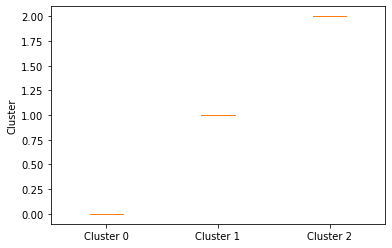

In [82]:
# Groupped Boxplots
i=0
for col in Bank_Data_HC5: 
    print(col) 
    plt.cla()
    plt.boxplot([Bank_Data_HC5.iloc[:,i][Bank_Data_HC5.Cluster==0].tolist(),
                 Bank_Data_HC5.iloc[:,i][Bank_Data_HC5.Cluster==1].tolist(),
                 Bank_Data_HC5.iloc[:,i][Bank_Data_HC5.Cluster==2].tolist()],
                 labels=('Cluster 0','Cluster 1','Cluster 2'))    
    plt.ylabel(col)
    plt.show()
    i=i+1

In [83]:
scaled_features

array([[ 0.55374135, -0.14910999],
       [-0.23262653,  0.16167351],
       [ 0.23594516, -0.07894152],
       ...,
       [ 0.03561106, -0.13813865],
       [-0.22833417, -0.0649176 ],
       [-0.14803291,  0.08080373]])

In [84]:
ac3.fit_predict(scaled_features)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [85]:
print(f"Silhouette Score for Hierarchical Clustering using single linkage: {silhouette_score(scaled_features, ac3.fit_predict(scaled_features))}")

Silhouette Score for Hierarchical Clustering using single linkage: 0.584821287709678


### 1.4 Spectral Clustering<a id="part1.4"></a>

#### 1.4.1 Model 6<a id="part1.4.1"></a>

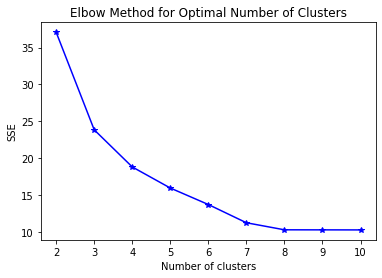

In [86]:
# Function to calculate SSE for hierarchical clustering
def calculate_sse(data, labels, cluster_centers):
    sse = 0
    for i, center in enumerate(cluster_centers):
        sse += np.sum((data[labels == i] - center) ** 2)
    return sse

# List to store SSE values
sse = []

# Loop over different number of clusters
for i in range(2, 11):
    sc = SpectralClustering(n_clusters=i, assign_labels='discretize',random_state=42)
    labels = sc.fit_predict(scaled_features)

    # Calculate cluster centers
    cluster_centers = np.array([scaled_features[labels == j].mean(axis=0) for j in range(i)])

    # Calculate SSE for the current number of clusters
    sse.append(calculate_sse(scaled_features, labels, cluster_centers))

# Plot the SSE values to visualize the elbow method
plt.plot(range(2, 11), sse, 'b-*')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [87]:
kl = KneeLocator(
    range(2, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

4

In [88]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    sc_k = SpectralClustering(n_clusters=k, assign_labels='discretize', random_state=42)
    silhouette_coefficients.append(silhouette_score(scaled_features, sc_k.fit_predict(scaled_features)))

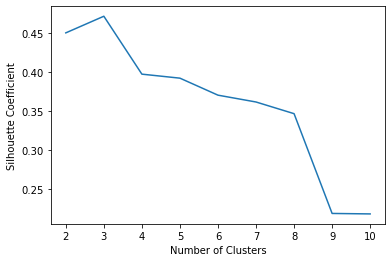

In [89]:
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

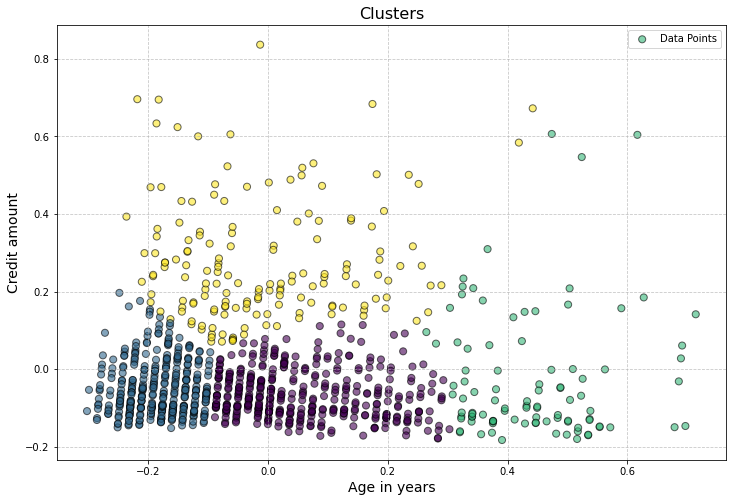

In [90]:
# Perform Spectral Clustering
sc4 = SpectralClustering(n_clusters=4, assign_labels='discretize', random_state=42).fit(scaled_features)
spectral_labels = sc4.labels_

# Plot Spectral Clustering results
plt.figure(figsize=(12, 8))
plt.scatter(scaled_features[:, 0], scaled_features[:, 1], c=spectral_labels, s=50, cmap='viridis', alpha=0.6, edgecolor='k', label='Data Points')
plt.xlabel('Age in years', fontsize=14)  
plt.ylabel('Credit amount', fontsize=14)
plt.title('Clusters', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [91]:
# Build the model using the optimal n_cluster

# Fit the model and assign each data point to the cluster
y_pred = sc4.fit_predict(scaled_features) # fit and then predict


Bank_Data_SC1 = Bank_Data.select_dtypes(include=[np.number])
Bank_Data_SC1['Cluster']=y_pred
Bank_Data_SC1.head()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target,Cluster
0,6,1169,4,4,67,2,1,1,2
1,48,5951,2,2,22,1,1,2,1
2,12,2096,2,3,49,1,2,1,0
3,42,7882,2,4,45,1,2,1,3
4,24,4870,3,4,53,2,2,2,2


Duration in month


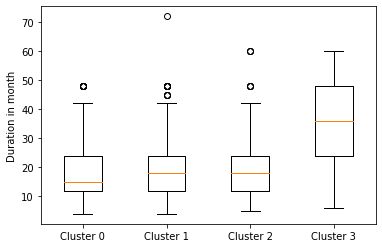

Credit amount


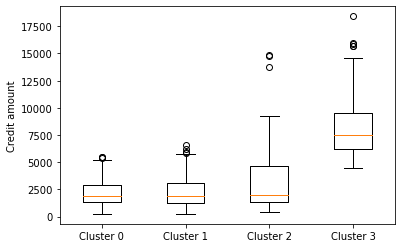

Instalment rate in percentage of disposable income


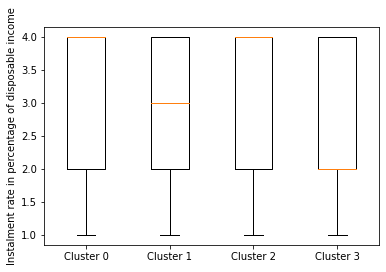

Present residence since


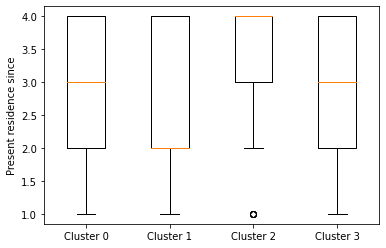

Age in years


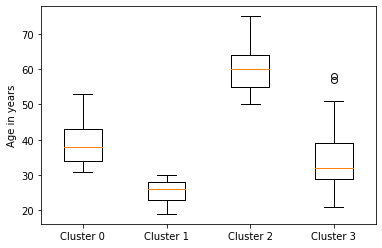

Number of existing credits at this bank


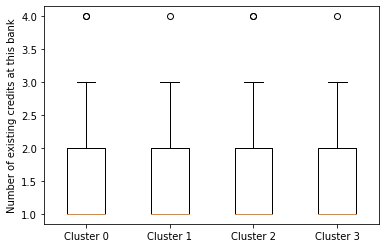

Number of people being liable to provide maintenance for


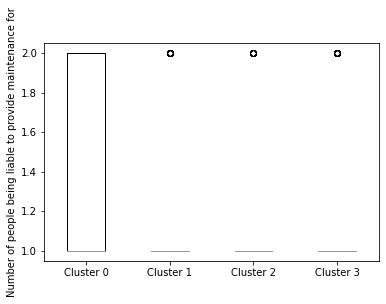

Target


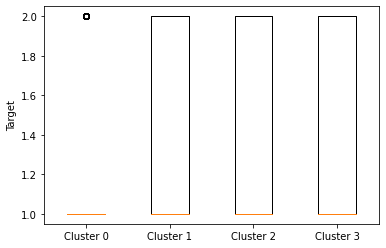

Cluster


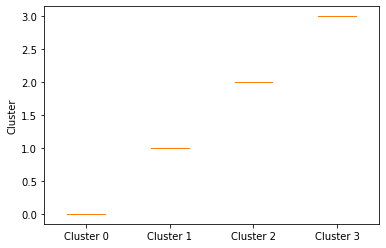

In [92]:
# Groupped Boxplots
i=0
for col in Bank_Data_SC1:
    print(col)
    plt.cla()
    plt.boxplot([Bank_Data_SC1.iloc[:,i][Bank_Data_SC1.Cluster == 0].tolist(),
        Bank_Data_SC1.iloc[:,i][Bank_Data_SC1.Cluster == 1].tolist(),
        Bank_Data_SC1.iloc[:,i][Bank_Data_SC1.Cluster == 2].tolist(),
        Bank_Data_SC1.iloc[:, i][Bank_Data_SC1.Cluster == 3].tolist()],
        labels=('Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'))
    plt.ylabel(col)
    plt.show()
    i=i+1

In [93]:
print(f"Silhouette Score for Spectral Clustering: {silhouette_score(scaled_features, spectral_labels)}")

Silhouette Score for Spectral Clustering: 0.3977484894609148
